# 05 — การสะสมฝนรายชั่วโมงและสถิติเชิงพื้นที่ตามเขตการปกครอง
## Hourly Radar Rainfall Accumulation and Administrative Zonal Statistics

**กรณีศึกษา**

- เรดาร์ตรวจอากาศกรมฝนหลวงและการบินเกษตร สถานี **อมก๋อย**
- เรดาร์ **S-band**
- ข้อมูลตัวอย่าง: 10 volume scans
- ช่วงเวลา: เริ่มจาก scan แรกและครอบคลุมช่วงเวลา 1 ชั่วโมง
- temporal sampling โดยประมาณ: 6 นาที
- spatial representation: **CAPPI 2 km MSL**
- horizontal grid spacing: **1 km**
- administrative boundaries:
  - ADM1 ≈ จังหวัด
  - ADM2 ≈ อำเภอ
- เวลาอ้างอิงหลัก: **UTC**
- รูปทั้งหมดใช้ภาษาอังกฤษเพื่อพร้อมนำไปปรับใช้ใน conference/journal

---

## แนวคิดหลักของบท

Notebook 04 ให้ผลลัพธ์เป็น **อัตราฝน**

\[
R_i \quad [mm\,h^{-1}]
\]

Notebook 05 จะเปลี่ยน rain rate ให้เป็น rainfall depth และสะสมตามเวลา

\[
P_i=R_i\Delta t_i
\]

จากนั้น

\[
P_{1h}=\sum_i P_i
\]

แล้วเชื่อมกับ GIS:

```text
Rain rate จากแต่ละ scan
        ↓
ตรวจ timestamp และ scan interval
        ↓
คำนวณ Δt จริง
        ↓
Rainfall depth รายช่วงเวลา
        ↓
สะสมเป็น hourly rainfall
        ↓
ตรวจ temporal coverage
        ↓
GeoTIFF
        ↓
ADM1 / ADM2
        ↓
Zonal statistics
        ↓
จัดอันดับพื้นที่ฝนมาก
```

> **หลักสำคัญ**
>
> `Rain rate ≠ rainfall accumulation`
>
> `Sum of dBZ is scientifically meaningless`
>
> `Missing scans matter`
>
> `Zonal statistics without coverage information can mislead`
>
> `Radar-derived rainfall ≠ ground truth`

# ผลลัพธ์การเรียนรู้

เมื่อจบ Notebook 05 ผู้เรียนควรสามารถ:

1. ตรวจสอบ timestamp ของ radar volume ทุกไฟล์
2. คำนวณ scan interval จากเวลาจริง
3. ตรวจจับ missing scan หรือ temporal gap
4. อธิบายความแตกต่างระหว่าง rain rate และ rainfall depth
5. คำนวณ rainfall depth จาก \(R_i\Delta t_i\)
6. สะสม rainfall เป็นช่วงเวลา 1 ชั่วโมง
7. อธิบายเหตุผลที่ไม่ควร sum ค่า dBZ
8. ใช้ grid geometry เดียวกันกับ radar volumes ทุก scan
9. สร้าง temporal-coverage raster
10. แยก supported dry pixel ออกจาก missing/no-data pixel
11. เปรียบเทียบ hourly rainfall จาก Z–R relations หลายชุด
12. สร้าง hourly-rainfall GeoTIFF
13. rasterize ADM1/ADM2 ให้ตรงกับ radar grid
14. คำนวณ mean, median, P90, P95 และ maximum rainfall รายเขต
15. คำนวณ wet-area fraction
16. คำนวณ valid-radar-coverage fraction
17. คำนวณพื้นที่ที่มีฝนเกิน threshold
18. คำนวณ rainfall volume โดยประมาณ
19. จัดอันดับพื้นที่ที่มีฝนมากโดยมี coverage criterion
20. สร้าง choropleth maps ระดับจังหวัดและอำเภอ
21. ตรวจสอบความสอดคล้องระหว่าง point accumulation กับ hourly raster
22. export metadata และ figure manifest เพื่อ reproducibility

# โครงสร้างการเรียนรู้

```text
Notebook 04
Rain rate (mm h⁻¹)
       ↓
Notebook 05
Time QC
       ↓
Temporal integration
       ↓
Hourly rainfall (mm)
       ↓
Temporal coverage
       ↓
GIS rasterization
       ↓
ADM1 / ADM2 zonal statistics
       ↓
Hydrometeorological interpretation
       ↓
Notebook 06
Vertical storm structure
```

# 1. ติดตั้งและตรวจสอบไลบรารีสำหรับ Google Colab

In [1]:
# CELL 1 — ติดตั้งไลบรารี

import sys
import subprocess

PACKAGE_SPECS = [
    "arm-pyart==2.2.5",
    "geopandas>=1.0",
    "pyogrio>=0.10",
    "cartopy>=0.23",
    "pyproj>=3.6",
    "shapely>=2.0",
    "pandas>=2.0",
    "matplotlib>=3.8",
    "netCDF4>=1.6",
    "rasterio>=1.4",
]

cmd = [
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade-strategy",
    "only-if-needed",
    *PACKAGE_SPECS,
]

print("กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 05 ...")
subprocess.check_call(cmd)
print("พร้อมใช้งาน")

กำลังติดตั้ง/ตรวจสอบไลบรารีสำหรับ Notebook 05 ...
พร้อมใช้งาน


# 2. เชื่อมต่อ Google Drive

In [2]:
# CELL 2 — Mount Google Drive

from pathlib import Path

try:
    from google.colab import drive

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

    DRIVE_ROOT = Path(
        "/content/drive/MyDrive"
    )

except ImportError:
    DRIVE_ROOT = Path.cwd()
    print("ไม่พบ google.colab")
    print("ใช้โฟลเดอร์ปัจจุบัน:", DRIVE_ROOT)

Mounted at /content/drive


# 3. นำเข้าไลบรารีและบันทึกเวอร์ชันซอฟต์แวร์

In [3]:
# CELL 3 — Imports

from __future__ import annotations

import gc
import gzip
import json
import math
import shutil
import sys
import tempfile
import time
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

import cartopy.crs as ccrs

import pyart

from pyproj import CRS, Transformer

import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_origin
from rasterio.warp import (
    calculate_default_transform,
    reproject,
    Resampling,
)

from netCDF4 import num2date
from IPython.display import display

warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

SOFTWARE_VERSIONS = {
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "matplotlib": matplotlib.__version__,
    "pyart": pyart.__version__,
    "geopandas": gpd.__version__,
    "rasterio": rasterio.__version__,
}

display(
    pd.DataFrame(
        SOFTWARE_VERSIONS.items(),
        columns=[
            "software",
            "version",
        ],
    )
)


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,rasterio,1.5.1


# 4. มาตรฐานการสร้างรูปสำหรับงานวิชาการ

In [4]:
# CELL 4 — Publication-ready figure settings

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.constrained_layout.use": True,
})

FIGURE_RECORDS = []


def save_figure(
    fig,
    path,
    *,
    source_file=None,
    product=None,
    relation_id=None,
    processing=None,
    units=None,
    time_window=None,
    dpi=300,
):
    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    fig.savefig(
        path,
        dpi=dpi,
        bbox_inches="tight",
        facecolor="white",
    )

    FIGURE_RECORDS.append({
        "figure_name": path.name,
        "figure_path": str(path),
        "source_file": source_file,
        "product": product,
        "relation_id": relation_id,
        "processing": processing,
        "units": units,
        "time_window": time_window,
        "dpi": dpi,
    })

    print("บันทึกรูป:", path)

# 5. อ่านสถานะจาก Notebook 01–04

Notebook 05 จะทำงานต่อเมื่อ Notebook 04 ผ่าน readiness check แล้ว

นอกจากนั้นจะอ่าน Z–R relation parameters จากไฟล์ output ของ Notebook 04 เพื่อไม่กำหนด coefficient ซ้ำและลดความเสี่ยงที่แต่ละ Notebook ใช้ parameter ไม่ตรงกัน

In [5]:
# CELL 5 — Course configuration

COURSE_NAME = "Teaching_DRRAA_WeatherRadar_GIS"

ROOT = (
    DRIVE_ROOT
    / COURSE_NAME
)

CONFIG_JSON = (
    ROOT
    / "00_config"
    / "course_config.json"
)

SETUP_STATUS_JSON = (
    ROOT
    / "99_logs"
    / "01_setup_status.json"
)

if not CONFIG_JSON.exists():
    raise FileNotFoundError(
        "ไม่พบ course_config.json — ให้รัน Notebook 01 ก่อน"
    )

with CONFIG_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    COURSE_CONFIG = json.load(
        stream
    )

with SETUP_STATUS_JSON.open(
    "r",
    encoding="utf-8",
) as stream:
    SETUP_STATUS = json.load(
        stream
    )

if not SETUP_STATUS.get(
    "ready",
    False,
):
    raise RuntimeError(
        "Notebook 01 ยังไม่ผ่าน readiness check"
    )

print("Notebook 01: PASS")

Notebook 01: PASS


In [6]:
# CELL 6 — Paths and Notebook 04 readiness

WORKSPACE = COURSE_CONFIG[
    "workspace"
]

RADAR_DIR = Path(
    WORKSPACE[
        "radar"
    ]
)

GIS_CANONICAL_DIR = Path(
    WORKSPACE[
        "gis_canonical"
    ]
)

OUTPUT_CSV_DIR = Path(
    WORKSPACE[
        "output_csv"
    ]
)

OUTPUT_GEOTIFF_DIR = Path(
    WORKSPACE[
        "output_geotiff"
    ]
)

OUTPUT_NETCDF_DIR = (
    ROOT
    / "03_output"
    / "netcdf"
)

FIGURE_DIR = (
    ROOT
    / "04_figures"
    / "05"
)

for folder in [
    OUTPUT_CSV_DIR,
    OUTPUT_GEOTIFF_DIR,
    OUTPUT_NETCDF_DIR,
    FIGURE_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

READINESS_04_CSV = (
    OUTPUT_CSV_DIR
    / "04_readiness_check.csv"
)

if not READINESS_04_CSV.exists():
    raise FileNotFoundError(
        "ไม่พบ 04_readiness_check.csv — ให้รัน Notebook 04 ก่อน"
    )

readiness_04 = pd.read_csv(
    READINESS_04_CSV
)

display(
    readiness_04
)

if not (
    readiness_04[
        "status"
    ]
    == "PASS"
).all():
    raise RuntimeError(
        "Notebook 04 ยังมีรายการที่ไม่ผ่าน"
    )

print("Notebook 04: PASS")

,item,status,note
0,Notebook 03 readiness,PASS,NaN
1,Active event is observed hail,PASS,NaN
2,Full-domain 3-D Grid NetCDF readable,PASS,NaN
3,Corrected reflectivity field available,PASS,NaN
4,QPE CAPPI extracted,PASS,2.0 km MSL
5,QPE CAPPI sampling diagnostic available,PASS,Nearest beam mismatch = 0.57 km
6,Three Z-R relations configured,PASS,NaN
7,Three rain-rate products created,PASS,NaN
8,No scientific upper ZH clipping,PASS,NaN
9,Supported weak-reflectivity pixels represented...,PASS,NaN


Notebook 04: PASS


# 6. Parameter block

ค่าหลัก:

- CAPPI = 2 km MSL
- grid spacing = 1 km
- grid extent = ±200 km
- corrected reflectivity threshold = 10 dBZ
- temporal coverage ที่ยอมรับสำหรับ hourly rainfall pixel = 80%
- zonal ranking จะใช้เฉพาะเขตที่มี valid-radar-coverage fraction ≥ 70%
- wet-area threshold = 0.1 mm
- heavy-rain area thresholds = 10 และ 20 mm

### แนวคิดสำคัญของ temporal integration

สำหรับแต่ละ scan:

\[
P_i=R_i\Delta t_i
\]

หากมี temporal gap ใหญ่กว่า 1.5 เท่าของ nominal interval จะ **ไม่ยืด rain rate ของ scan เดิมให้ครอบคลุม gap ทั้งหมด**

วิธีนี้ช่วยไม่ให้ missing scan ถูกเติมโดยปริยาย

In [7]:
# CELL 7 — Notebook 05 parameters

FIELD_Z = "corrected_reflectivity"

QPE_CAPPI_MSL_KM = 2.0

QPE_ZH_MIN_DBZ = 10.0

GRID_HALF_WIDTH_KM = 200.0
GRID_SPACING_KM = 1.0

WEIGHTING_FUNCTION = "Barnes2"
ROI_FUNCTION = "dist_beam"
MIN_RADIUS_M = 500.0
ROI_NB = 1.0
ROI_BSP = 1.0
ROI_H_FACTOR = (
    1.0,
    1.0,
    1.0,
)

GAP_FACTOR = 1.5

MIN_TEMPORAL_COVERAGE_FRACTION = 0.80
MIN_ZONE_RADAR_COVERAGE_FRACTION = 0.70

WET_RAIN_THRESHOLD_MM = 0.1

AREA_THRESHOLD_1_MM = 10.0
AREA_THRESHOLD_2_MM = 20.0

TOP_ADM1_N = 10
TOP_ADM2_N = 20

HOURLY_RAIN_BOUNDS_MM = [
    0.0,
    0.5,
    1.0,
    2.0,
    5.0,
    10.0,
    15.0,
    20.0,
    30.0,
    50.0,
    75.0,
    100.0,
]

GEOTIFF_NODATA = -9999.0

print("โหลด Notebook 05 parameters แล้ว")

โหลด Notebook 05 parameters แล้ว


# 7. อ่าน Z–R relation parameters จาก Notebook 04

In [8]:
# CELL 8 — Load Z-R parameters from Notebook 04

ZR_PARAMETER_CSV = (
    OUTPUT_CSV_DIR
    / "04_ZR_relation_parameters.csv"
)

if not ZR_PARAMETER_CSV.exists():
    raise FileNotFoundError(
        "ไม่พบ 04_ZR_relation_parameters.csv"
    )

zr_parameter_table = pd.read_csv(
    ZR_PARAMETER_CSV
)

required_columns = {
    "relation_id",
    "label",
    "a",
    "b",
    "equation",
}

missing_columns = (
    required_columns
    - set(
        zr_parameter_table.columns
    )
)

if missing_columns:
    raise RuntimeError(
        f"Z-R parameter table ขาด columns: {missing_columns}"
    )

ZR_RELATIONS = {}

for _, row in (
    zr_parameter_table.iterrows()
):
    ZR_RELATIONS[
        str(
            row[
                "relation_id"
            ]
        )
    ] = {
        "label": str(
            row[
                "label"
            ]
        ),
        "a": float(
            row[
                "a"
            ]
        ),
        "b": float(
            row[
                "b"
            ]
        ),
        "equation": str(
            row[
                "equation"
            ]
        ),
    }

RELATION_IDS = list(
    ZR_RELATIONS.keys()
)

BASE_RELATION = (
    "MP_200_1.6"
    if "MP_200_1.6"
    in ZR_RELATIONS
    else RELATION_IDS[0]
)

display(
    zr_parameter_table[
        [
            "relation_id",
            "label",
            "a",
            "b",
            "equation",
        ]
    ]
)

print(
    "Baseline relation:",
    BASE_RELATION,
)

,relation_id,label,a,b,equation
0,MP_200_1.6,Marshall–Palmer,200.0,1.6,Z = 200 R^1.6
1,CONV_300_1.4,Convective-like,300.0,1.4,Z = 300 R^1.4
2,TROP_250_1.2,Tropical-like,250.0,1.2,Z = 250 R^1.2


Baseline relation: MP_200_1.6


# 8. ฟังก์ชันสำหรับอ่าน radar และจัดการเวลา

In [9]:
# CELL 9 — Radar I/O helper

RADAR_CACHE = (
    Path(
        tempfile.gettempdir()
    )
    / "drraa_radar_uf_cache"
)

RADAR_CACHE.mkdir(
    parents=True,
    exist_ok=True,
)


def read_radar_file(
    path,
):
    path = Path(
        path
    )

    try:
        return pyart.io.read(
            str(
                path
            )
        )

    except Exception as direct_error:

        if path.suffix.lower() != ".gz":
            raise

        unpacked = (
            RADAR_CACHE
            / path.with_suffix(
                ""
            ).name
        )

        if not unpacked.exists():

            with gzip.open(
                path,
                "rb",
            ) as source, unpacked.open(
                "wb"
            ) as target:

                shutil.copyfileobj(
                    source,
                    target,
                )

        try:
            return pyart.io.read(
                str(
                    unpacked
                )
            )

        except Exception as unpacked_error:

            raise RuntimeError(
                f"อ่านไฟล์ {path.name} ไม่สำเร็จ "
                f"(compressed={direct_error!r}; "
                f"unpacked={unpacked_error!r})"
            ) from unpacked_error

In [10]:
# CELL 10 — Time helper

LOCAL_TIMEZONE = (
    COURSE_CONFIG[
        "time"
    ][
        "local_timezone"
    ]
)


def radar_datetime_utc(
    radar,
):
    units = radar.time.get(
        "units"
    )

    if units is None:
        return pd.NaT

    text = str(
        units
    ).upper()

    if not (
        "Z" in text
        or "UTC" in text
        or "+00:00" in text
    ):
        raise ValueError(
            "Radar time units ไม่ได้ระบุ UTC อย่างชัดเจน"
        )

    dt = num2date(
        radar.time[
            "data"
        ][0],
        units=units,
        calendar=radar.time.get(
            "calendar",
            "standard",
        ),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )

    ts = pd.Timestamp(
        dt
    )

    if ts.tzinfo is None:
        ts = ts.tz_localize(
            "UTC"
        )
    else:
        ts = ts.tz_convert(
            "UTC"
        )

    return ts

# 9. ตรวจเวลา radar volumes ทั้งหมด

Notebook นี้ไม่สมมติว่า:

```text
มี 10 files = ครบ 1 ชั่วโมงเสมอ
```

แต่จะอ่านเวลาออกจาก radar object ทุกไฟล์ แล้ว:

1. เรียงตาม timestamp
2. คำนวณ interval จริง
3. หา nominal interval จาก median
4. ตรวจ gap
5. สร้าง analysis window ความยาว 1 ชั่วโมงจาก scan แรก

In [11]:
# CELL 11 — Radar time inventory

RADAR_FILES = list(
    COURSE_CONFIG[
        "radar"
    ][
        "source_files"
    ]
)

time_rows = []

for index, filename in enumerate(
    RADAR_FILES,
    start=1,
):
    print(
        f"ตรวจเวลา {index:02d}/{len(RADAR_FILES)}: "
        f"{filename}"
    )

    radar_i = read_radar_file(
        RADAR_DIR
        / filename
    )

    utc_i = radar_datetime_utc(
        radar_i
    )

    time_rows.append({
        "filename": filename,
        "time_UTC": utc_i,
        "time_ICT": utc_i.tz_convert(
            LOCAL_TIMEZONE
        ),
        "nsweeps": int(
            radar_i.nsweeps
        ),
    })

    del radar_i
    gc.collect()


scan_time_inventory = (
    pd.DataFrame(
        time_rows
    )
    .sort_values(
        "time_UTC"
    )
    .reset_index(
        drop=True
    )
)

scan_time_inventory[
    "interval_to_previous_min"
] = (
    scan_time_inventory[
        "time_UTC"
    ]
    .diff()
    .dt.total_seconds()
    / 60.0
)

display(
    scan_time_inventory
)

ตรวจเวลา 01/10: 20230318110609.uf.gz
ตรวจเวลา 02/10: 20230318111202.uf.gz
ตรวจเวลา 03/10: 20230318111802.uf.gz
ตรวจเวลา 04/10: 20230318112402.uf.gz
ตรวจเวลา 05/10: 20230318113002.uf.gz
ตรวจเวลา 06/10: 20230318113602.uf.gz
ตรวจเวลา 07/10: 20230318114202.uf.gz
ตรวจเวลา 08/10: 20230318114802.uf.gz
ตรวจเวลา 09/10: 20230318115402.uf.gz
ตรวจเวลา 10/10: 20230318120002.uf.gz


,filename,time_UTC,time_ICT,nsweeps,interval_to_previous_min
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,2023-03-18 18:06:09+07:00,14,NaN
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,2023-03-18 18:12:02+07:00,14,5.883333
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,2023-03-18 18:18:02+07:00,14,6.000000
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,2023-03-18 18:24:02+07:00,14,6.000000
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,2023-03-18 18:30:02+07:00,14,6.000000
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,2023-03-18 18:36:02+07:00,14,6.000000
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,2023-03-18 18:42:02+07:00,14,6.000000
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,2023-03-18 18:48:02+07:00,14,6.000000
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,2023-03-18 18:54:02+07:00,14,6.000000
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,2023-03-18 19:00:02+07:00,14,6.000000


In [12]:
# CELL 12 — Nominal interval and analysis window

valid_intervals_min = (
    scan_time_inventory[
        "interval_to_previous_min"
    ]
    .dropna()
)

if valid_intervals_min.empty:
    raise RuntimeError(
        "ไม่สามารถคำนวณ nominal scan interval ได้"
    )

NOMINAL_INTERVAL_MIN = float(
    valid_intervals_min.median()
)

NOMINAL_INTERVAL_H = (
    NOMINAL_INTERVAL_MIN
    / 60.0
)

ANALYSIS_START_UTC = (
    scan_time_inventory.loc[
        0,
        "time_UTC",
    ]
)

ANALYSIS_END_UTC = (
    ANALYSIS_START_UTC
    + pd.Timedelta(
        hours=1
    )
)

ANALYSIS_DURATION_H = (
    (
        ANALYSIS_END_UTC
        - ANALYSIS_START_UTC
    ).total_seconds()
    / 3600.0
)

print(
    "Nominal interval:",
    f"{NOMINAL_INTERVAL_MIN:.2f} min",
)

print(
    "Analysis start:",
    ANALYSIS_START_UTC,
)

print(
    "Analysis end  :",
    ANALYSIS_END_UTC,
)

Nominal interval: 6.00 min
Analysis start: 2023-03-18 11:06:09+00:00
Analysis end  : 2023-03-18 12:06:09+00:00


# 10. กำหนด \(\Delta t_i\) สำหรับแต่ละ scan

หลักการ:

- ถ้า scan ถัดไปอยู่ใกล้ nominal interval → ใช้ actual interval
- ถ้า gap ใหญ่กว่า `GAP_FACTOR × nominal interval` → ให้ scan ปัจจุบันแทนเวลาเพียง nominal interval และปล่อยช่วงที่เหลือเป็น missing
- scan สุดท้ายแทนเวลาได้ไม่เกิน nominal interval
- duration ถูก clip ให้อยู่ภายใน 1-hour analysis window

วิธีนี้เป็น **conservative interval integration** และไม่ silently fill missing scans

In [13]:
# CELL 13 — Build temporal integration weights

integration_rows = []

times = list(
    scan_time_inventory[
        "time_UTC"
    ]
)

nominal_seconds = (
    NOMINAL_INTERVAL_MIN
    * 60.0
)

gap_threshold_seconds = (
    GAP_FACTOR
    * nominal_seconds
)

for i, current_time in enumerate(
    times
):
    if current_time >= ANALYSIS_END_UTC:
        used_seconds = 0.0
        actual_gap_seconds = np.nan
        gap_flag = False

    else:
        if i < len(
            times
        ) - 1:
            next_time = times[
                i + 1
            ]

            actual_gap_seconds = (
                next_time
                - current_time
            ).total_seconds()

            if (
                actual_gap_seconds
                <= gap_threshold_seconds
            ):
                proposed_seconds = (
                    actual_gap_seconds
                )
                gap_flag = False
            else:
                proposed_seconds = (
                    nominal_seconds
                )
                gap_flag = True

        else:
            actual_gap_seconds = np.nan
            proposed_seconds = (
                nominal_seconds
            )
            gap_flag = False

        available_to_window_end = max(
            0.0,
            (
                ANALYSIS_END_UTC
                - current_time
            ).total_seconds(),
        )

        used_seconds = min(
            proposed_seconds,
            available_to_window_end,
        )

    integration_rows.append({
        "filename": (
            scan_time_inventory.loc[
                i,
                "filename",
            ]
        ),
        "time_UTC": current_time,
        "actual_gap_to_next_min": (
            actual_gap_seconds
            / 60.0
            if np.isfinite(
                actual_gap_seconds
            )
            else np.nan
        ),
        "integration_duration_min": (
            used_seconds
            / 60.0
        ),
        "integration_duration_h": (
            used_seconds
            / 3600.0
        ),
        "gap_flag": gap_flag,
    })


scan_interval_qc = pd.DataFrame(
    integration_rows
)

TOTAL_INTEGRATED_DURATION_H = float(
    scan_interval_qc[
        "integration_duration_h"
    ].sum()
)

TEMPORAL_COMPLETENESS = (
    TOTAL_INTEGRATED_DURATION_H
    / ANALYSIS_DURATION_H
)

display(
    scan_interval_qc
)

print()
print(
    "Integrated duration:",
    f"{TOTAL_INTEGRATED_DURATION_H * 60:.2f} min",
)

print(
    "Temporal completeness:",
    f"{TEMPORAL_COMPLETENESS:.1%}",
)

SCAN_INTERVAL_QC_CSV = (
    OUTPUT_CSV_DIR
    / "05_scan_interval_QC.csv"
)

scan_interval_qc.to_csv(
    SCAN_INTERVAL_QC_CSV,
    index=False,
)

,filename,time_UTC,actual_gap_to_next_min,integration_duration_min,integration_duration_h,gap_flag
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,5.883333,5.883333,0.098056,False
1,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,6.000000,6.000000,0.100000,False
2,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,6.000000,6.000000,0.100000,False
3,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,6.000000,6.000000,0.100000,False
4,20230318113002.uf.gz,2023-03-18 11:30:02+00:00,6.000000,6.000000,0.100000,False
5,20230318113602.uf.gz,2023-03-18 11:36:02+00:00,6.000000,6.000000,0.100000,False
6,20230318114202.uf.gz,2023-03-18 11:42:02+00:00,6.000000,6.000000,0.100000,False
7,20230318114802.uf.gz,2023-03-18 11:48:02+00:00,6.000000,6.000000,0.100000,False
8,20230318115402.uf.gz,2023-03-18 11:54:02+00:00,6.000000,6.000000,0.100000,False
9,20230318120002.uf.gz,2023-03-18 12:00:02+00:00,NaN,6.000000,0.100000,False



Integrated duration: 59.88 min
Temporal completeness: 99.8%


# 11. แสดง scan-interval QC ในรูปแบบ publication-ready

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig01_scan_interval_QC.png


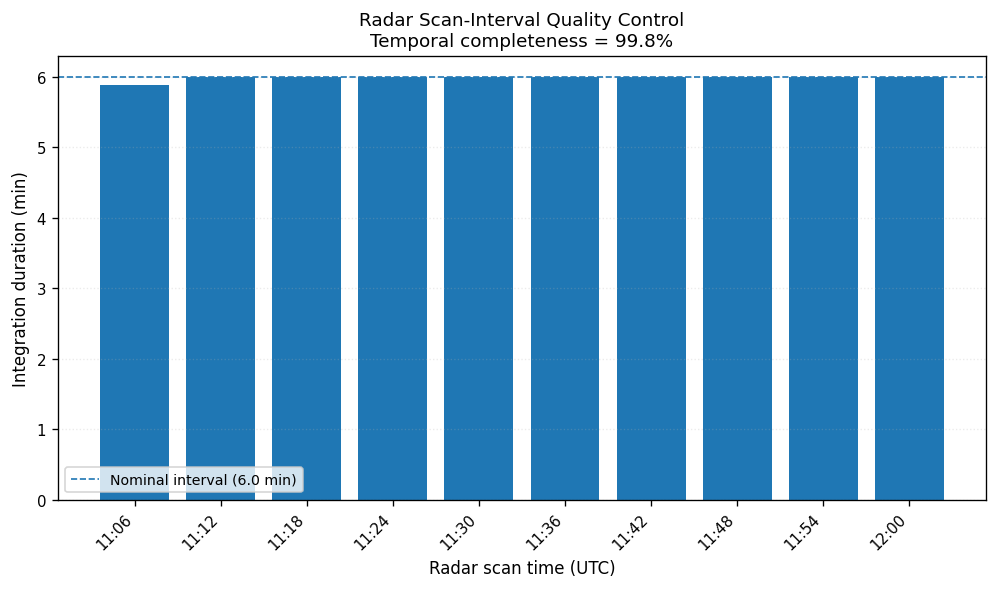

In [14]:
# CELL 14 — Scan interval QC figure

fig = plt.figure(
    figsize=(8.2, 4.8)
)

ax = fig.add_subplot(
    111
)

plot_x = np.arange(
    len(
        scan_interval_qc
    )
)

ax.bar(
    plot_x,
    scan_interval_qc[
        "integration_duration_min"
    ],
)

ax.axhline(
    NOMINAL_INTERVAL_MIN,
    linestyle="--",
    linewidth=1.0,
    label=(
        f"Nominal interval "
        f"({NOMINAL_INTERVAL_MIN:.1f} min)"
    ),
)

ax.set_xticks(
    plot_x
)

ax.set_xticklabels(
    [
        pd.Timestamp(
            value
        ).strftime(
            "%H:%M"
        )
        for value in (
            scan_interval_qc[
                "time_UTC"
            ]
        )
    ],
    rotation=45,
    ha="right",
)

ax.set_xlabel(
    "Radar scan time (UTC)"
)

ax.set_ylabel(
    "Integration duration (min)"
)

ax.set_title(
    (
        "Radar Scan-Interval Quality Control\n"
        f"Temporal completeness = "
        f"{TEMPORAL_COMPLETENESS:.1%}"
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
    linestyle=":",
)

ax.legend(
    frameon=True,
)

SCAN_INTERVAL_FIG = (
    FIGURE_DIR
    / "05_fig01_scan_interval_QC.png"
)

save_figure(
    fig,
    SCAN_INTERVAL_FIG,
    product="scan interval QC",
    processing=(
        "Actual radar timestamps; conservative interval integration."
    ),
    units="minutes",
    time_window=(
        f"{ANALYSIS_START_UTC} to "
        f"{ANALYSIS_END_UTC}"
    ),
)

plt.show()

# 12. หลักการสะสมฝนจาก radar-supported pixels

ใน Notebook 04 ค่า reflectivity ต่ำกว่า threshold ถูก mask สำหรับการคำนวณ QPE ราย scan

แต่สำหรับ **การสะสมฝนรายชั่วโมง** ต้องแยกให้ชัดระหว่าง:

```text
supported pixel + ZH < threshold
→ rain rate = 0

unsupported / missing radar pixel
→ NoData
```

หากนำ pixel ที่มี ZH ต่ำกว่า threshold ไปนับเป็น missing จะทำให้ valid coverage ต่ำผิดความจริง

ดังนั้น Notebook 05 ใช้ 2 masks แยกกัน:

```text
radar_support_mask
qpe_rain_mask
```

In [15]:
# CELL 15 — dBZ → rain-rate helper

def dbz_to_z(
    dbz,
):
    values = np.asarray(
        dbz,
        dtype=float,
    )

    return (
        10.0
        ** (
            values
            / 10.0
        )
    )


def dbz_to_rain_rate(
    dbz,
    a,
    b,
):
    z = dbz_to_z(
        dbz
    )

    return (
        z
        / float(
            a
        )
    ) ** (
        1.0
        / float(
            b
        )
    )

# 13. ฟังก์ชันสร้าง single-level CAPPI ด้วย grid geometry เดียวกันทุก scan

In [16]:
# CELL 16 — Single-level grid helper

def build_single_level_grid(
    radar_object,
    *,
    height_msl_km,
):
    nxy = int(
        round(
            (
                2.0
                * GRID_HALF_WIDTH_KM
            )
            / GRID_SPACING_KM
        )
        + 1
    )

    z_m = (
        height_msl_km
        * 1000.0
    )

    gatefilter = (
        pyart.filters.GateFilter(
            radar_object
        )
    )

    gatefilter.exclude_invalid(
        FIELD_Z
    )

    gatefilter.exclude_masked(
        FIELD_Z
    )

    return (
        pyart.map.grid_from_radars(
            (
                radar_object,
            ),
            grid_shape=(
                1,
                nxy,
                nxy,
            ),
            grid_limits=(
                (
                    z_m,
                    z_m,
                ),
                (
                    -GRID_HALF_WIDTH_KM
                    * 1000.0,
                    GRID_HALF_WIDTH_KM
                    * 1000.0,
                ),
                (
                    -GRID_HALF_WIDTH_KM
                    * 1000.0,
                    GRID_HALF_WIDTH_KM
                    * 1000.0,
                ),
            ),
            grid_origin=(
                float(
                    radar_object.latitude[
                        "data"
                    ][0]
                ),
                float(
                    radar_object.longitude[
                        "data"
                    ][0]
                ),
            ),
            grid_origin_alt=0.0,
            fields=[
                FIELD_Z
            ],
            gatefilters=gatefilter,
            gridding_algo=(
                "map_gates_to_grid"
            ),
            weighting_function=(
                WEIGHTING_FUNCTION
            ),
            roi_func=(
                ROI_FUNCTION
            ),
            min_radius=(
                MIN_RADIUS_M
            ),
            nb=ROI_NB,
            bsp=ROI_BSP,
            h_factor=(
                ROI_H_FACTOR
            ),
            map_roi=False,
        )
    )

# 14. ประมวลผล 10 scans และสะสมฝน

สำหรับแต่ละ scan:

1. สร้าง CAPPI 2 km MSL
2. หา radar-supported pixels
3. กำหนด rain rate = 0 เมื่อ radar support มีอยู่แต่ ZH < 10 dBZ
4. คำนวณ rain rate เมื่อ ZH ≥ 10 dBZ
5. คูณด้วย \(\Delta t_i\)
6. สะสม rainfall depth
7. สะสม support duration

ผลลัพธ์สุดท้าย:

```text
hourly_rainfall[relation]
support_duration
temporal_coverage_fraction
```

In [17]:
# CELL 17 — Initialize accumulation arrays

nxy = int(
    round(
        (
            2.0
            * GRID_HALF_WIDTH_KM
        )
        / GRID_SPACING_KM
    )
    + 1
)

GRID_SHAPE_2D = (
    nxy,
    nxy,
)

HOURLY_ACCUMULATION = {
    relation_id: np.zeros(
        GRID_SHAPE_2D,
        dtype=np.float64,
    )
    for relation_id in RELATION_IDS
}

SUPPORT_DURATION_H = np.zeros(
    GRID_SHAPE_2D,
    dtype=np.float64,
)

SCAN_QPE_ROWS = []

GRID_TEMPLATE = None

print(
    "Accumulator shape:",
    GRID_SHAPE_2D,
)

Accumulator shape: (401, 401)


In [18]:
# CELL 18 — Process all radar volumes

for index, row in (
    scan_interval_qc.iterrows()
):
    filename = row[
        "filename"
    ]

    duration_h = float(
        row[
            "integration_duration_h"
        ]
    )

    print()
    print(
        f"[{index + 1:02d}/{len(scan_interval_qc)}] "
        f"{filename}"
    )

    if duration_h <= 0:
        print(
            "  integration duration = 0; skip"
        )
        continue

    radar_i = read_radar_file(
        RADAR_DIR
        / filename
    )

    scan_time_utc = radar_datetime_utc(
        radar_i
    )

    start = time.perf_counter()

    grid_i = build_single_level_grid(
        radar_i,
        height_msl_km=(
            QPE_CAPPI_MSL_KM
        ),
    )

    elapsed = (
        time.perf_counter()
        - start
    )

    if GRID_TEMPLATE is None:
        GRID_TEMPLATE = grid_i

    zh_i = np.ma.asarray(
        grid_i.fields[
            FIELD_Z
        ][
            "data"
        ][0]
    )

    zh_values_i = zh_i.filled(
        np.nan
    )

    support_mask_i = (
        ~np.ma.getmaskarray(
            zh_i
        )
        & np.isfinite(
            zh_values_i
        )
    )

    SUPPORT_DURATION_H[
        support_mask_i
    ] += duration_h

    qpe_mask_i = (
        support_mask_i
        & (
            zh_values_i
            >= QPE_ZH_MIN_DBZ
        )
    )

    for relation_id in (
        RELATION_IDS
    ):
        p = ZR_RELATIONS[
            relation_id
        ]

        # Supported-but-dry pixels are zero rain.
        rain_rate_i = np.zeros(
            GRID_SHAPE_2D,
            dtype=np.float64,
        )

        rain_rate_i[
            qpe_mask_i
        ] = dbz_to_rain_rate(
            zh_values_i[
                qpe_mask_i
            ],
            p[
                "a"
            ],
            p[
                "b"
            ],
        )

        # Only radar-supported pixels contribute to the accumulation.
        HOURLY_ACCUMULATION[
            relation_id
        ][
            support_mask_i
        ] += (
            rain_rate_i[
                support_mask_i
            ]
            * duration_h
        )

        valid_rain_values = (
            rain_rate_i[
                support_mask_i
            ]
        )

        SCAN_QPE_ROWS.append({
            "filename": filename,
            "time_UTC": (
                scan_time_utc
            ),
            "integration_duration_min": (
                duration_h
                * 60.0
            ),
            "relation_id": (
                relation_id
            ),
            "radar_supported_pixel_count": int(
                support_mask_i.sum()
            ),
            "QPE_wet_pixel_count": int(
                qpe_mask_i.sum()
            ),
            "mean_rain_rate_mm_h": (
                float(
                    np.nanmean(
                        valid_rain_values
                    )
                )
                if valid_rain_values.size
                else np.nan
            ),
            "max_rain_rate_mm_h": (
                float(
                    np.nanmax(
                        valid_rain_values
                    )
                )
                if valid_rain_values.size
                else np.nan
            ),
            "gridding_seconds": (
                elapsed
            ),
        })

    del grid_i
    del radar_i
    del zh_i
    del zh_values_i
    gc.collect()


scan_qpe_summary = pd.DataFrame(
    SCAN_QPE_ROWS
)

display(
    scan_qpe_summary.head(
        12
    )
)

SCAN_QPE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "05_scan_QPE_summary.csv"
)

scan_qpe_summary.to_csv(
    SCAN_QPE_SUMMARY_CSV,
    index=False,
)


[01/10] 20230318110609.uf.gz

[02/10] 20230318111202.uf.gz

[03/10] 20230318111802.uf.gz

[04/10] 20230318112402.uf.gz

[05/10] 20230318113002.uf.gz

[06/10] 20230318113602.uf.gz

[07/10] 20230318114202.uf.gz

[08/10] 20230318114802.uf.gz

[09/10] 20230318115402.uf.gz

[10/10] 20230318120002.uf.gz


,filename,time_UTC,integration_duration_min,relation_id,radar_supported_pixel_count,QPE_wet_pixel_count,mean_rain_rate_mm_h,max_rain_rate_mm_h,gridding_seconds
0,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,5.883333,MP_200_1.6,12802,7639,3.853587,336.285844,0.752565
1,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,5.883333,CONV_300_1.4,12802,7639,4.928280,577.946296,0.752565
2,20230318110609.uf.gz,2023-03-18 11:06:09+00:00,5.883333,TROP_250_1.2,12802,7639,11.848172,1941.719253,0.752565
3,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,6.000000,MP_200_1.6,12327,7730,4.328134,485.108274,0.757791
4,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,6.000000,CONV_300_1.4,12327,7730,5.483957,878.517570,0.757791
5,20230318111202.uf.gz,2023-03-18 11:12:02+00:00,6.000000,TROP_250_1.2,12327,7730,13.137759,3164.899318,0.757791
6,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,6.000000,MP_200_1.6,11919,7515,5.156593,342.599844,0.876460
7,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,6.000000,CONV_300_1.4,11919,7515,6.527919,590.364374,0.876460
8,20230318111802.uf.gz,2023-03-18 11:18:02+00:00,6.000000,TROP_250_1.2,11919,7515,15.429365,1990.480239,0.876460
9,20230318112402.uf.gz,2023-03-18 11:24:02+00:00,6.000000,MP_200_1.6,12285,7661,5.143417,449.426754,1.178262


# 15. สร้าง temporal-coverage fraction

In [19]:
# CELL 19 — Temporal coverage

if GRID_TEMPLATE is None:
    raise RuntimeError(
        "ไม่มี GRID_TEMPLATE จากการประมวลผล radar"
    )

TEMPORAL_COVERAGE = (
    SUPPORT_DURATION_H
    / ANALYSIS_DURATION_H
)

TEMPORAL_COVERAGE = np.clip(
    TEMPORAL_COVERAGE,
    0.0,
    1.0,
)

HOURLY_VALID_MASK = (
    TEMPORAL_COVERAGE
    >= MIN_TEMPORAL_COVERAGE_FRACTION
)

coverage_values = (
    TEMPORAL_COVERAGE[
        TEMPORAL_COVERAGE
        > 0
    ]
)

temporal_coverage_summary = pd.DataFrame({
    "metric": [
        "analysis_duration_h",
        "dataset_temporal_completeness",
        "minimum_pixel_temporal_coverage_for_hourly_product",
        "pixels_with_any_radar_support",
        "pixels_meeting_hourly_temporal_coverage",
        "median_temporal_coverage_of_supported_pixels",
        "P10_temporal_coverage_of_supported_pixels",
    ],
    "value": [
        ANALYSIS_DURATION_H,
        TEMPORAL_COMPLETENESS,
        MIN_TEMPORAL_COVERAGE_FRACTION,
        int(
            (
                TEMPORAL_COVERAGE
                > 0
            ).sum()
        ),
        int(
            HOURLY_VALID_MASK.sum()
        ),
        (
            float(
                np.nanmedian(
                    coverage_values
                )
            )
            if coverage_values.size
            else np.nan
        ),
        (
            float(
                np.nanpercentile(
                    coverage_values,
                    10,
                )
            )
            if coverage_values.size
            else np.nan
        ),
    ],
})

display(
    temporal_coverage_summary
)

TEMPORAL_COVERAGE_CSV = (
    OUTPUT_CSV_DIR
    / "05_temporal_coverage_summary.csv"
)

temporal_coverage_summary.to_csv(
    TEMPORAL_COVERAGE_CSV,
    index=False,
)

,metric,value
0,analysis_duration_h,1.000000
1,dataset_temporal_completeness,0.998056
2,minimum_pixel_temporal_coverage_for_hourly_pro...,0.800000
3,pixels_with_any_radar_support,29404.000000
4,pixels_meeting_hourly_temporal_coverage,6514.000000
5,median_temporal_coverage_of_supported_pixels,0.400000
6,P10_temporal_coverage_of_supported_pixels,0.100000


# 16. สร้าง hourly-rainfall products ที่ใช้ coverage criterion

ค่าฝนสะสมจะมี 2 รูปแบบ:

```text
raw accumulation
→ เก็บผลคำนวณทุก pixel ที่มี radar support บางช่วงเวลา

analysis-ready hourly rainfall
→ ใช้เฉพาะ pixel ที่ temporal coverage ≥ 80%
```

การแยกสองชุดนี้ช่วยรักษา provenance และป้องกันการตีความ pixel ที่ข้อมูลไม่ครบเป็น hourly total ที่สมบูรณ์

In [20]:
# CELL 20 — Mask hourly rainfall by temporal coverage

HOURLY_RAINFALL = {}

for relation_id in (
    RELATION_IDS
):
    raw = HOURLY_ACCUMULATION[
        relation_id
    ]

    analysis_ready = np.ma.array(
        raw,
        mask=(
            ~HOURLY_VALID_MASK
        ),
    )

    HOURLY_RAINFALL[
        relation_id
    ] = (
        analysis_ready
    )

print(
    "Hourly products:",
    list(
        HOURLY_RAINFALL.keys()
    ),
)

Hourly products: ['MP_200_1.6', 'CONV_300_1.4', 'TROP_250_1.2']


# 17. สรุป hourly rainfall จากแต่ละ Z–R relation

In [21]:
# CELL 21 — Hourly rainfall summary

hourly_summary_rows = []

for relation_id, rainfall in (
    HOURLY_RAINFALL.items()
):
    values = (
        np.ma.asarray(
            rainfall
        ).compressed()
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    if values.size == 0:
        continue

    hourly_summary_rows.append({
        "relation_id": (
            relation_id
        ),
        "label": (
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
        "valid_pixel_count": int(
            values.size
        ),
        "mean_hourly_rainfall_mm": float(
            np.nanmean(
                values
            )
        ),
        "median_hourly_rainfall_mm": float(
            np.nanmedian(
                values
            )
        ),
        "P90_hourly_rainfall_mm": float(
            np.nanpercentile(
                values,
                90,
            )
        ),
        "P95_hourly_rainfall_mm": float(
            np.nanpercentile(
                values,
                95,
            )
        ),
        "max_hourly_rainfall_mm": float(
            np.nanmax(
                values
            )
        ),
        "wet_area_fraction": float(
            (
                values
                >= WET_RAIN_THRESHOLD_MM
            ).mean()
        ),
        "fraction_ge_10mm": float(
            (
                values
                >= AREA_THRESHOLD_1_MM
            ).mean()
        ),
        "fraction_ge_20mm": float(
            (
                values
                >= AREA_THRESHOLD_2_MM
            ).mean()
        ),
    })


hourly_qpe_summary = (
    pd.DataFrame(
        hourly_summary_rows
    )
)

display(
    hourly_qpe_summary
)

HOURLY_QPE_SUMMARY_CSV = (
    OUTPUT_CSV_DIR
    / "05_hourly_QPE_summary.csv"
)

hourly_qpe_summary.to_csv(
    HOURLY_QPE_SUMMARY_CSV,
    index=False,
)

,relation_id,label,valid_pixel_count,mean_hourly_rainfall_mm,median_hourly_rainfall_mm,P90_hourly_rainfall_mm,P95_hourly_rainfall_mm,max_hourly_rainfall_mm,wet_area_fraction,fraction_ge_10mm,fraction_ge_20mm
0,MP_200_1.6,Marshall–Palmer,6514,6.158573,1.492733,17.987332,24.062721,132.092925,0.836199,0.219374,0.079828
1,CONV_300_1.4,Convective-like,6514,7.652762,1.273763,22.852494,31.397830,219.934288,0.820387,0.242247,0.121277
2,TROP_250_1.2,Tropical-like,6514,17.599028,1.738154,52.457990,77.018119,718.663157,0.817931,0.314707,0.241480


# 18. เตรียม geographic coordinates และ administrative boundaries สำหรับการแสดงผล

In [22]:
# CELL 22 — Geographic coordinates and clipped GIS

grid_lon, grid_lat = (
    GRID_TEMPLATE.get_point_longitude_latitude(
        level=0
    )
)

radar_lon = float(
    GRID_TEMPLATE.origin_longitude[
        "data"
    ][0]
)

radar_lat = float(
    GRID_TEMPLATE.origin_latitude[
        "data"
    ][0]
)

lon_min = float(
    np.nanmin(
        grid_lon
    )
)

lon_max = float(
    np.nanmax(
        grid_lon
    )
)

lat_min = float(
    np.nanmin(
        grid_lat
    )
)

lat_max = float(
    np.nanmax(
        grid_lat
    )
)

GIS_GPKG = (
    GIS_CANONICAL_DIR
    / "thailand_admin_boundaries.gpkg"
)

adm1 = gpd.read_file(
    GIS_GPKG,
    layer="adm1",
)

adm2 = gpd.read_file(
    GIS_GPKG,
    layer="adm2",
)

adm1_clip = adm1.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

adm2_clip = adm2.cx[
    lon_min:lon_max,
    lat_min:lat_max
].copy()

print(
    "ADM1 in radar domain:",
    len(
        adm1_clip
    ),
)

print(
    "ADM2 in radar domain:",
    len(
        adm2_clip
    ),
)

ADM1 in radar domain: 15
ADM2 in radar domain: 124


# 19. กำหนด colormap สำหรับ hourly rainfall

In [23]:
# CELL 23 — Hourly-rainfall colormap

def resolve_hourly_rain_colormap():
    for name in [
        "RRate11",
        "turbo",
        "viridis",
    ]:
        if name in matplotlib.colormaps:
            return name

    return "viridis"


HOURLY_CMAP_NAME = (
    resolve_hourly_rain_colormap()
)

HOURLY_CMAP = plt.get_cmap(
    HOURLY_CMAP_NAME,
    len(
        HOURLY_RAIN_BOUNDS_MM
    ) - 1,
)

HOURLY_NORM = BoundaryNorm(
    HOURLY_RAIN_BOUNDS_MM,
    HOURLY_CMAP.N,
    clip=True,
)

print(
    "Hourly-rainfall colormap:",
    HOURLY_CMAP_NAME,
)

Hourly-rainfall colormap: RRate11


# 20. Temporal-coverage map

ก่อนดู hourly rainfall ต้องดู temporal coverage ควบคู่กัน

pixel ที่ไม่มี coverage เพียงพอจะไม่ถูกใช้เป็น analysis-ready hourly rainfall

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig02_temporal_coverage.png


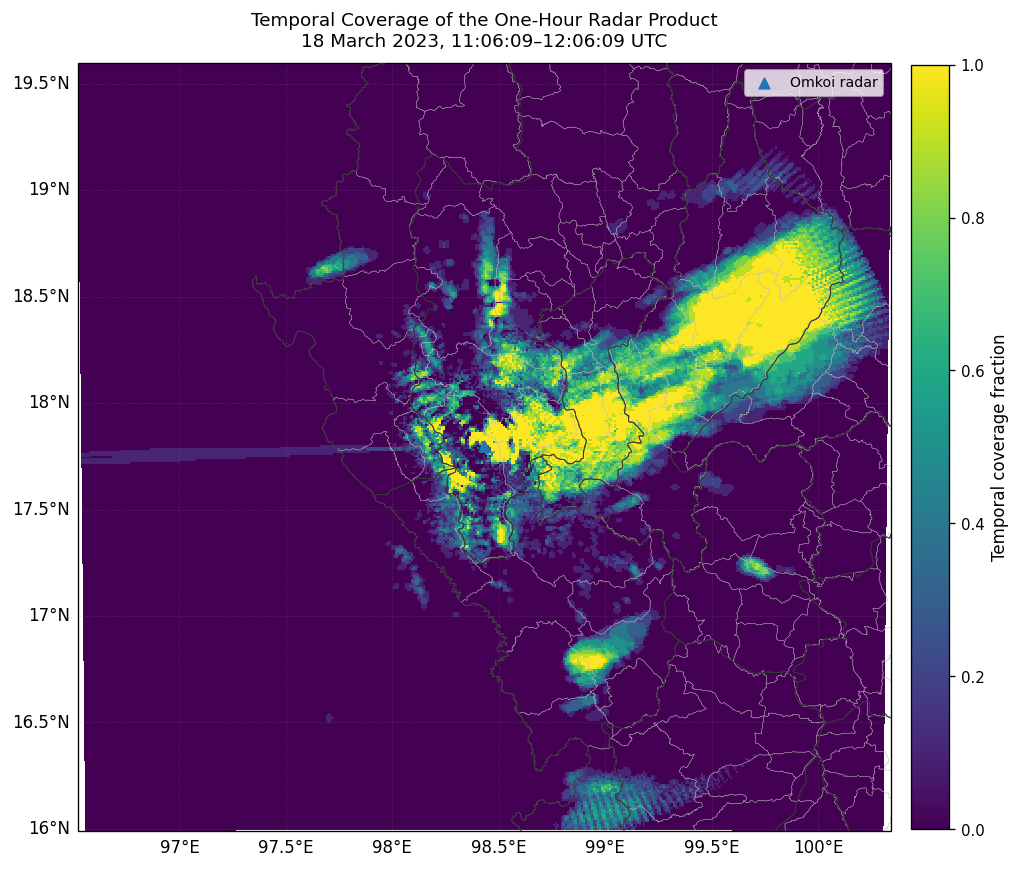

In [24]:
# CELL 24 — Temporal coverage figure

projection = ccrs.PlateCarree()

fig = plt.figure(
    figsize=(
        8.4,
        7.4,
    )
)

ax = plt.axes(
    projection=projection
)

ax.set_extent(
    [
        lon_min,
        lon_max,
        lat_min,
        lat_max,
    ],
    crs=projection,
)

mesh = ax.pcolormesh(
    grid_lon,
    grid_lat,
    TEMPORAL_COVERAGE,
    transform=projection,
    shading="auto",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    rasterized=True,
    zorder=1,
)

for geom in (
    adm2_clip.geometry
):
    ax.add_geometries(
        [
            geom
        ],
        crs=projection,
        facecolor="none",
        edgecolor="0.75",
        linewidth=0.20,
        zorder=2,
    )

for geom in (
    adm1_clip.geometry
):
    ax.add_geometries(
        [
            geom
        ],
        crs=projection,
        facecolor="none",
        edgecolor="0.22",
        linewidth=0.55,
        zorder=3,
    )

ax.scatter(
    radar_lon,
    radar_lat,
    transform=projection,
    marker="^",
    s=40,
    label="Omkoi radar",
    zorder=4,
)

gridliner = ax.gridlines(
    crs=projection,
    draw_labels=True,
    linewidth=0.40,
    alpha=0.30,
    linestyle=":",
)

gridliner.top_labels = False
gridliner.right_labels = False

cbar = fig.colorbar(
    mesh,
    ax=ax,
    pad=0.025,
    shrink=0.88,
)

cbar.set_label(
    "Temporal coverage fraction"
)

ax.set_title(
    (
        "Temporal Coverage of the One-Hour Radar Product\n"
        f"{ANALYSIS_START_UTC.strftime('%d %B %Y, %H:%M:%S')}–"
        f"{ANALYSIS_END_UTC.strftime('%H:%M:%S UTC')}"
    ),
    pad=10,
)

ax.legend(
    loc="upper right",
    frameon=True,
)

TEMPORAL_COVERAGE_FIG = (
    FIGURE_DIR
    / "05_fig02_temporal_coverage.png"
)

save_figure(
    fig,
    TEMPORAL_COVERAGE_FIG,
    product="temporal coverage",
    processing=(
        "Accumulated radar-support duration divided by one-hour analysis duration."
    ),
    units="fraction",
    time_window=(
        f"{ANALYSIS_START_UTC} to "
        f"{ANALYSIS_END_UTC}"
    ),
)

plt.show()

# 21. Publication-ready hourly rainfall maps

ทุก relation ใช้:

- spatial domain เดียวกัน
- CAPPI 2 km MSL
- grid spacing 1 km
- temporal-coverage criterion เดียวกัน
- rainfall bins เดียวกัน
- administrative boundaries เดียวกัน

จึงสามารถเปรียบเทียบกันได้อย่างเป็นธรรม

In [25]:
# CELL 25 — Hourly rainfall plotting function

def plot_hourly_rainfall(
    rainfall,
    *,
    relation_id,
    output_path,
):
    projection = (
        ccrs.PlateCarree()
    )

    fig = plt.figure(
        figsize=(
            8.4,
            7.4,
        )
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            lon_min,
            lon_max,
            lat_min,
            lat_max,
        ],
        crs=projection,
    )

    # Display-only masking of very small totals.
    display_rain = np.ma.masked_less(
        np.ma.asarray(
            rainfall
        ),
        0.1,
    )

    mesh = ax.pcolormesh(
        grid_lon,
        grid_lat,
        display_rain,
        transform=projection,
        shading="auto",
        cmap=HOURLY_CMAP,
        norm=HOURLY_NORM,
        rasterized=True,
        zorder=1,
    )

    for geom in (
        adm2_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.75",
            linewidth=0.20,
            zorder=2,
        )

    for geom in (
        adm1_clip.geometry
    ):
        ax.add_geometries(
            [
                geom
            ],
            crs=projection,
            facecolor="none",
            edgecolor="0.22",
            linewidth=0.55,
            zorder=3,
        )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=40,
        label="Omkoi radar",
        zorder=4,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.40,
        alpha=0.30,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    cbar = fig.colorbar(
        mesh,
        ax=ax,
        pad=0.025,
        shrink=0.88,
        boundaries=(
            HOURLY_RAIN_BOUNDS_MM
        ),
        ticks=(
            HOURLY_RAIN_BOUNDS_MM[
                1:-1
            ]
        ),
        extend="max",
    )

    cbar.set_label(
        "Hourly radar-derived rainfall (mm)"
    )

    p = ZR_RELATIONS[
        relation_id
    ]

    ax.set_title(
        (
            "Omkoi S-band Weather Radar — "
            "One-Hour Radar-Derived Rainfall\n"
            f"CAPPI {QPE_CAPPI_MSL_KM:.1f} km MSL | "
            f"{p['label']} ({p['equation']})"
        ),
        pad=10,
    )

    ax.legend(
        loc="upper right",
        frameon=True,
    )

    save_figure(
        fig,
        output_path,
        product="hourly radar rainfall",
        relation_id=relation_id,
        processing=(
            f"Interval integration; ZH >= {QPE_ZH_MIN_DBZ:.1f} dBZ; "
            f"pixel temporal coverage >= "
            f"{MIN_TEMPORAL_COVERAGE_FRACTION:.0%}; "
            "values below 0.1 mm masked for display only."
        ),
        units="mm",
        time_window=(
            f"{ANALYSIS_START_UTC} to "
            f"{ANALYSIS_END_UTC}"
        ),
    )

    plt.show()

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_hourly_rainfall_MP_200_1.6.png


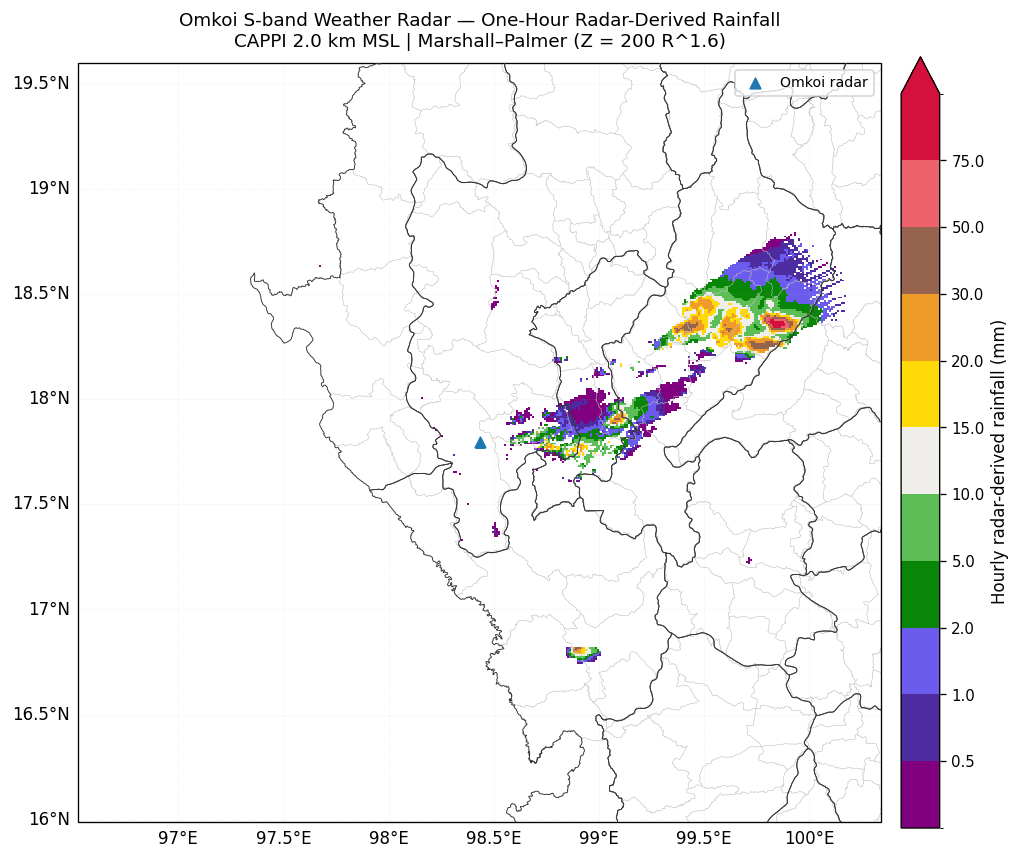

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_hourly_rainfall_CONV_300_1.4.png


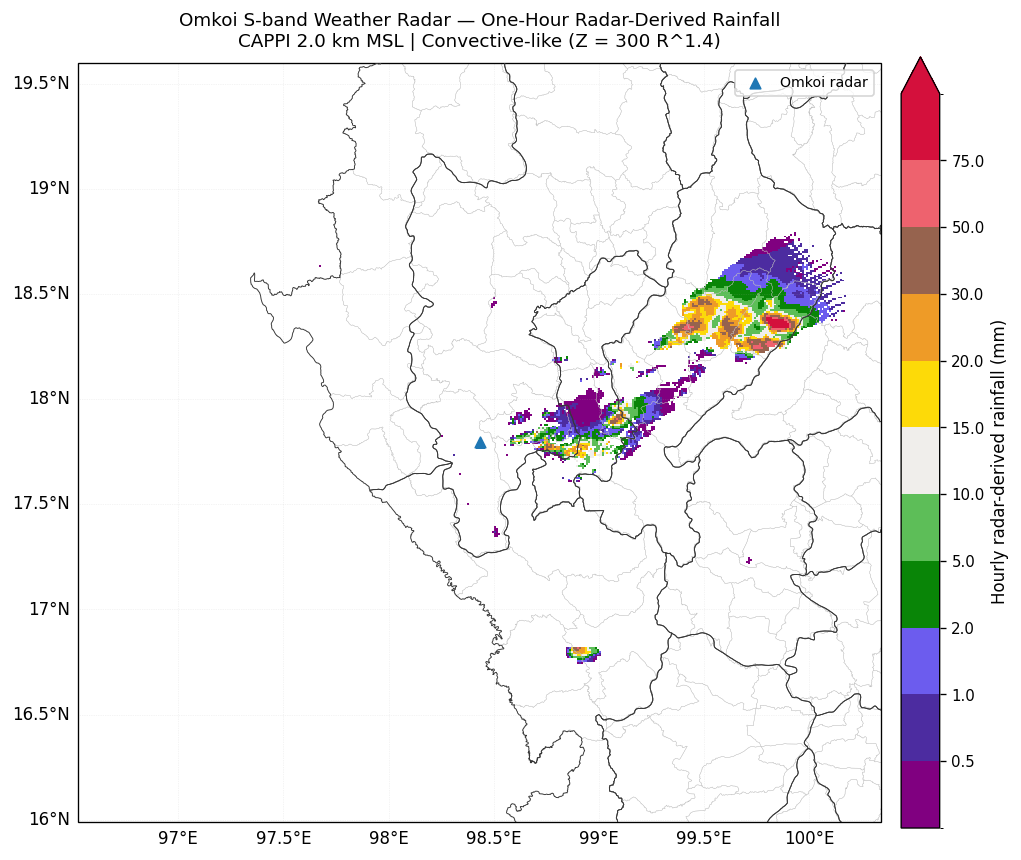

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_hourly_rainfall_TROP_250_1.2.png


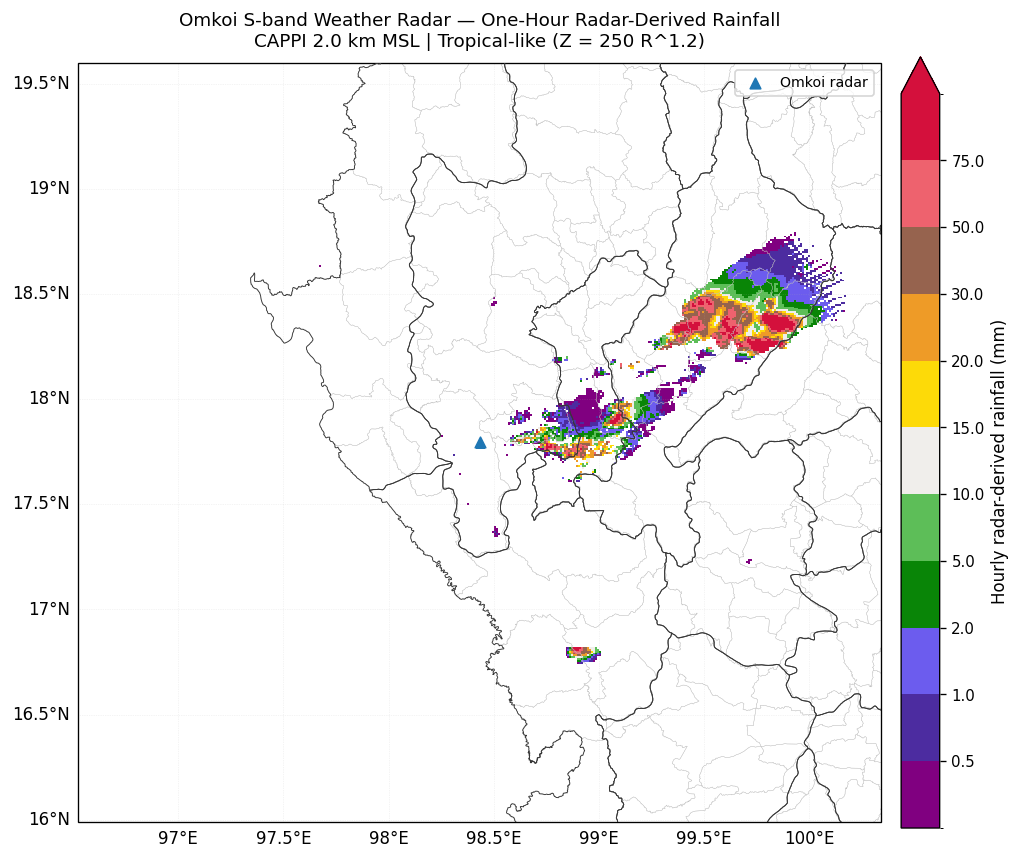

In [26]:
# CELL 26 — Export hourly rainfall figures

HOURLY_RAIN_FIGURES = {}

for relation_id, rainfall in (
    HOURLY_RAINFALL.items()
):
    output_path = (
        FIGURE_DIR
        / (
            "05_hourly_rainfall_"
            f"{relation_id}.png"
        )
    )

    plot_hourly_rainfall(
        rainfall,
        relation_id=(
            relation_id
        ),
        output_path=(
            output_path
        ),
    )

    HOURLY_RAIN_FIGURES[
        relation_id
    ] = output_path

# 22. เปรียบเทียบ hourly QPE distributions

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig06_hourly_rainfall_distribution.png


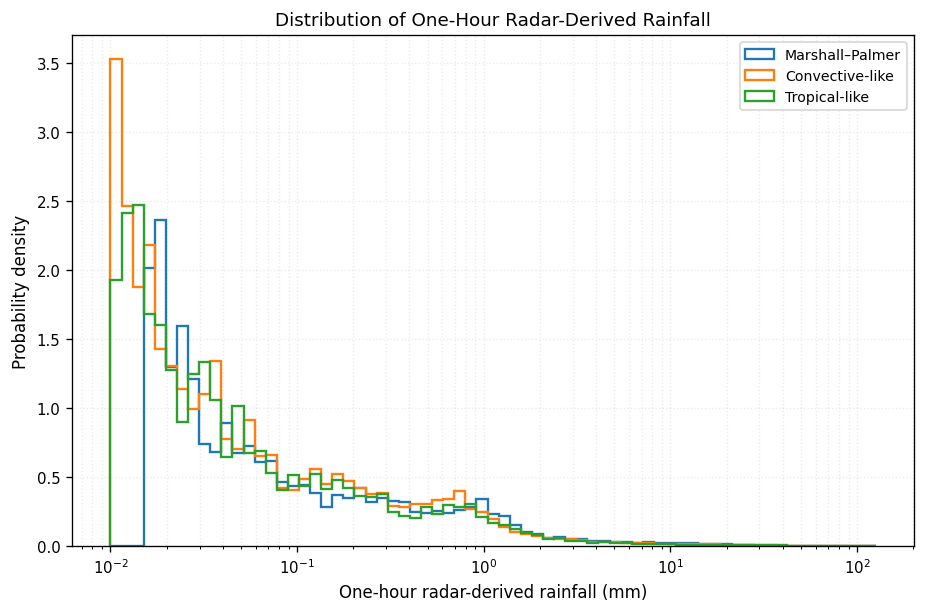

In [27]:
# CELL 27 — Hourly QPE distribution figure

fig = plt.figure(
    figsize=(
        7.6,
        5.0,
    )
)

ax = fig.add_subplot(
    111
)

for relation_id, rainfall in (
    HOURLY_RAINFALL.items()
):
    values = (
        np.ma.asarray(
            rainfall
        ).compressed()
    )

    values = values[
        np.isfinite(
            values
        )
    ]

    wet_values = values[
        values
        > 0
    ]

    if wet_values.size == 0:
        continue

    ax.hist(
        wet_values,
        bins=np.logspace(
            -2,
            2.1,
            70,
        ),
        density=True,
        histtype="step",
        linewidth=1.4,
        label=(
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
    )

ax.set_xscale(
    "log"
)

ax.set_xlabel(
    "One-hour radar-derived rainfall (mm)"
)

ax.set_ylabel(
    "Probability density"
)

ax.set_title(
    "Distribution of One-Hour Radar-Derived Rainfall"
)

ax.grid(
    alpha=0.25,
    linestyle=":",
    which="both",
)

ax.legend(
    frameon=True,
)

HOURLY_DIST_FIG = (
    FIGURE_DIR
    / "05_fig06_hourly_rainfall_distribution.png"
)

save_figure(
    fig,
    HOURLY_DIST_FIG,
    product="hourly rainfall distribution",
    processing=(
        "Wet analysis-ready pixels only; "
        "comparison among Z-R relations."
    ),
    units="mm",
    time_window=(
        f"{ANALYSIS_START_UTC} to "
        f"{ANALYSIS_END_UTC}"
    ),
)

plt.show()

# 23. เตรียม native radar projection และ GeoTIFF geometry

Zonal statistics จะคำนวณบน **native 1-km radar Cartesian grid** เพื่อหลีกเลี่ยงการ resample ก่อนสถิติ

UTM GeoTIFF จะถูกสร้างเพิ่มเติมสำหรับการใช้งาน GIS ภายนอก

In [28]:
# CELL 28 — Native AEQD raster geometry

PYART_SPHERE_RADIUS_M = (
    6370997.0
)

NATIVE_AEQD_CRS = (
    CRS.from_proj4(
        (
            f"+proj=aeqd "
            f"+lat_0={radar_lat} "
            f"+lon_0={radar_lon} "
            f"+R={PYART_SPHERE_RADIUS_M} "
            "+units=m "
            "+no_defs"
        )
    )
)

x = np.asarray(
    GRID_TEMPLATE.x[
        "data"
    ],
    dtype=float,
)

y = np.asarray(
    GRID_TEMPLATE.y[
        "data"
    ],
    dtype=float,
)

dx_m = float(
    np.nanmedian(
        np.diff(
            x
        )
    )
)

dy_m = float(
    np.nanmedian(
        np.diff(
            y
        )
    )
)

west = float(
    x.min()
    - dx_m
    / 2.0
)

north = float(
    y.max()
    + dy_m
    / 2.0
)

native_transform = (
    from_origin(
        west,
        north,
        dx_m,
        dy_m,
    )
)

PIXEL_AREA_M2 = (
    abs(
        dx_m
        * dy_m
    )
)

PIXEL_AREA_KM2 = (
    PIXEL_AREA_M2
    / 1e6
)

print(
    "Native pixel size:",
    f"{dx_m:.0f} × {dy_m:.0f} m",
)

print(
    "Pixel area:",
    f"{PIXEL_AREA_KM2:.3f} km²",
)

Native pixel size: 1000 × 1000 m
Pixel area: 1.000 km²


# 24. Export hourly rainfall และ temporal coverage เป็น GeoTIFF

In [29]:
# CELL 29 — Generic raster export helper

def write_native_geotiff(
    array_internal,
    *,
    output_path,
    units,
    product,
    relation_id=None,
    nodata=GEOTIFF_NODATA,
):
    output_path = Path(
        output_path
    )

    # Internal grid: y increases south→north.
    # Raster rows: north→south.
    raster_array = np.flipud(
        np.ma.asarray(
            array_internal
        ).filled(
            nodata
        )
    ).astype(
        "float32"
    )

    with rasterio.open(
        output_path,
        "w",
        driver="GTiff",
        height=raster_array.shape[
            0
        ],
        width=raster_array.shape[
            1
        ],
        count=1,
        dtype="float32",
        crs=(
            NATIVE_AEQD_CRS
        ),
        transform=(
            native_transform
        ),
        nodata=nodata,
        compress="deflate",
    ) as dst:

        dst.write(
            raster_array,
            1,
        )

        dst.update_tags(
            radar_site="Omkoi",
            product=product,
            relation_id=(
                relation_id
                if relation_id
                is not None
                else ""
            ),
            units=units,
            CAPPI_height_km_MSL=(
                QPE_CAPPI_MSL_KM
            ),
            analysis_start_UTC=(
                str(
                    ANALYSIS_START_UTC
                )
            ),
            analysis_end_UTC=(
                str(
                    ANALYSIS_END_UTC
                )
            ),
            temporal_coverage_threshold=(
                MIN_TEMPORAL_COVERAGE_FRACTION
            ),
        )

    return output_path

In [30]:
# CELL 30 — Native GeoTIFF products

NATIVE_HOURLY_GEOTIFFS = {}

for relation_id, rainfall in (
    HOURLY_RAINFALL.items()
):
    output_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "05_hourly_rainfall_"
            f"{relation_id}_"
            "native_AEQD.tif"
        )
    )

    NATIVE_HOURLY_GEOTIFFS[
        relation_id
    ] = write_native_geotiff(
        rainfall,
        output_path=(
            output_path
        ),
        units="mm",
        product=(
            "one-hour radar-derived rainfall"
        ),
        relation_id=(
            relation_id
        ),
    )


TEMPORAL_COVERAGE_GEOTIFF = (
    OUTPUT_GEOTIFF_DIR
    / "05_temporal_coverage_native_AEQD.tif"
)

write_native_geotiff(
    np.ma.asarray(
        TEMPORAL_COVERAGE
    ),
    output_path=(
        TEMPORAL_COVERAGE_GEOTIFF
    ),
    units="fraction",
    product=(
        "temporal radar coverage"
    ),
)

print(
    "Native hourly GeoTIFFs created:",
    len(
        NATIVE_HOURLY_GEOTIFFS
    ),
)

Native hourly GeoTIFFs created: 3


In [31]:
# CELL 31 — Automatic UTM CRS

def utm_from_lon_lat(
    lon,
    lat,
):
    zone = int(
        np.floor(
            (
                lon
                + 180.0
            )
            / 6.0
        )
        + 1
    )

    if lat >= 0:
        epsg = (
            32600
            + zone
        )
        hemisphere = "N"
    else:
        epsg = (
            32700
            + zone
        )
        hemisphere = "S"

    return {
        "zone": zone,
        "hemisphere": (
            hemisphere
        ),
        "epsg": epsg,
        "crs": CRS.from_epsg(
            epsg
        ),
    }


UTM_INFO = (
    utm_from_lon_lat(
        radar_lon,
        radar_lat,
    )
)

print(
    "UTM:",
    f"{UTM_INFO['zone']}"
    f"{UTM_INFO['hemisphere']}",
)

print(
    "EPSG:",
    UTM_INFO[
        "epsg"
    ],
)

UTM: 47N
EPSG: 32647


In [32]:
# CELL 32 — Reproject GeoTIFF helper

def reproject_to_utm(
    native_path,
    utm_path,
    *,
    resampling,
):
    native_path = Path(
        native_path
    )

    utm_path = Path(
        utm_path
    )

    with rasterio.open(
        native_path
    ) as src:

        dst_transform, dst_width, dst_height = (
            calculate_default_transform(
                src.crs,
                UTM_INFO[
                    "crs"
                ],
                src.width,
                src.height,
                *src.bounds,
                resolution=(
                    GRID_SPACING_KM
                    * 1000.0
                ),
            )
        )

        profile = (
            src.profile.copy()
        )

        profile.update({
            "crs": (
                UTM_INFO[
                    "crs"
                ]
            ),
            "transform": (
                dst_transform
            ),
            "width": (
                dst_width
            ),
            "height": (
                dst_height
            ),
            "compress": (
                "deflate"
            ),
        })

        with rasterio.open(
            utm_path,
            "w",
            **profile
        ) as dst:

            reproject(
                source=(
                    rasterio.band(
                        src,
                        1,
                    )
                ),
                destination=(
                    rasterio.band(
                        dst,
                        1,
                    )
                ),
                src_transform=(
                    src.transform
                ),
                src_crs=(
                    src.crs
                ),
                src_nodata=(
                    src.nodata
                ),
                dst_transform=(
                    dst_transform
                ),
                dst_crs=(
                    UTM_INFO[
                        "crs"
                    ]
                ),
                dst_nodata=(
                    src.nodata
                ),
                resampling=(
                    resampling
                ),
            )

    return utm_path

In [33]:
# CELL 33 — UTM GeoTIFF products

UTM_HOURLY_GEOTIFFS = {}

for relation_id, native_path in (
    NATIVE_HOURLY_GEOTIFFS.items()
):
    utm_path = (
        OUTPUT_GEOTIFF_DIR
        / (
            "05_hourly_rainfall_"
            f"{relation_id}_"
            f"UTM{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}.tif"
        )
    )

    UTM_HOURLY_GEOTIFFS[
        relation_id
    ] = reproject_to_utm(
        native_path,
        utm_path,
        resampling=(
            Resampling.bilinear
        ),
    )


TEMPORAL_COVERAGE_UTM_GEOTIFF = (
    OUTPUT_GEOTIFF_DIR
    / (
        "05_temporal_coverage_"
        f"UTM{UTM_INFO['zone']}"
        f"{UTM_INFO['hemisphere']}.tif"
    )
)

reproject_to_utm(
    TEMPORAL_COVERAGE_GEOTIFF,
    TEMPORAL_COVERAGE_UTM_GEOTIFF,
    resampling=(
        Resampling.nearest
    ),
)

print(
    "UTM hourly GeoTIFFs created:",
    len(
        UTM_HOURLY_GEOTIFFS
    ),
)

UTM hourly GeoTIFFs created: 3


# 25. Zonal statistics — หลักการ

เป้าหมายคือสรุป hourly radar rainfall ตามขอบเขตการปกครอง

```text
hourly rainfall raster
        +
ADM1 / ADM2 polygons
        ↓
rasterize polygons to the same 1-km radar grid
        ↓
group pixels by zone
        ↓
zonal statistics
```

Notebook นี้คำนวณสถิติบน **native radar Cartesian grid** ก่อน reproject เพื่อหลีกเลี่ยงการเปลี่ยนค่าจาก resampling

ค่า `all_touched=False` หมายความว่า pixel จะถูกกำหนดให้เขตใดเมื่อ **จุดศูนย์กลางของ pixel** อยู่ใน polygon เป็นหลัก

นี่เป็น processing choice ที่ต้องรายงาน

In [34]:
# CELL 34 — Reproject administrative boundaries to native radar CRS

adm1_native = (
    adm1_clip.to_crs(
        NATIVE_AEQD_CRS
    )
)

adm2_native = (
    adm2_clip.to_crs(
        NATIVE_AEQD_CRS
    )
)

print(
    "ADM1 native CRS features:",
    len(adm1_native),
)

print(
    "ADM2 native CRS features:",
    len(adm2_native),
)

ADM1 native CRS features: 15
ADM2 native CRS features: 124


In [35]:
# CELL 35 — Build zone-code lookup tables

def prepare_zone_layer(
    gdf,
    *,
    level_name,
):
    working = (
        gdf.copy()
        .reset_index(drop=True)
    )

    working[
        "zone_code"
    ] = np.arange(
        1,
        len(working) + 1,
        dtype=np.int32,
    )

    required = [
        "zone_code",
        "shapeName",
        "shapeID",
        "shapeISO",
        "geometry",
    ]

    for column in required:
        if column not in working.columns:
            if column == "shapeISO":
                working[column] = ""
            else:
                raise KeyError(
                    f"{level_name}: missing {column}"
                )

    lookup = working[
        [
            "zone_code",
            "shapeName",
            "shapeID",
            "shapeISO",
        ]
    ].copy()

    lookup[
        "admin_level"
    ] = level_name

    return working, lookup


adm1_native, adm1_lookup = (
    prepare_zone_layer(
        adm1_native,
        level_name="ADM1",
    )
)

adm2_native, adm2_lookup = (
    prepare_zone_layer(
        adm2_native,
        level_name="ADM2",
    )
)

display(
    adm1_lookup.head()
)

display(
    adm2_lookup.head()
)

,zone_code,shapeName,shapeID,shapeISO,admin_level
0,1,Phayao Province,36821470B12194119812739,TH-56,ADM1
1,2,Nakhon Sawan Province,36821470B58837026258254,TH-60,ADM1
2,3,Sukhothai Province,36821470B85895478064474,TH-64,ADM1
3,4,Phitsanulok Province,36821470B89877881758540,TH-65,ADM1
4,5,Chiang Rai Province,36821470B41943429581493,TH-57,ADM1


,zone_code,shapeName,shapeID,shapeISO,admin_level
0,1,Ban Dan Lan Hoi,78962969B72722062907305,,ADM2
1,2,Ban Hong,78962969B26085596744311,,ADM2
2,3,Ban Luang,78962969B2609342993216,,ADM2
3,4,Ban Tak,78962969B53904723449117,,ADM2
4,5,Ban Thi,78962969B75208473855809,,ADM2


In [36]:
# CELL 36 — Rasterize administrative zones

def rasterize_zones(
    zone_gdf,
):
    shapes = [
        (
            geom,
            int(code),
        )
        for geom, code
        in zip(
            zone_gdf.geometry,
            zone_gdf["zone_code"],
        )
        if (
            geom is not None
            and not geom.is_empty
        )
    ]

    return rasterize(
        shapes=shapes,
        out_shape=GRID_SHAPE_2D,
        transform=native_transform,
        fill=0,
        all_touched=False,
        dtype="int32",
    )


ADM1_ZONE_RASTER = (
    rasterize_zones(
        adm1_native
    )
)

ADM2_ZONE_RASTER = (
    rasterize_zones(
        adm2_native
    )
)

print(
    "ADM1 raster zones:",
    len(
        np.unique(
            ADM1_ZONE_RASTER[
                ADM1_ZONE_RASTER > 0
            ]
        )
    ),
)

print(
    "ADM2 raster zones:",
    len(
        np.unique(
            ADM2_ZONE_RASTER[
                ADM2_ZONE_RASTER > 0
            ]
        )
    ),
)

ADM1 raster zones: 14
ADM2 raster zones: 122


# 26. Coverage metrics สำหรับ zonal statistics

สำหรับแต่ละเขต จะรายงานอย่างน้อย:

- `zone_pixel_count`
- `valid_pixel_count`
- `radar_coverage_fraction`
- `mean`
- `median`
- `P90`
- `P95`
- `max`
- `wet_area_fraction`
- area ≥ 10 mm
- area ≥ 20 mm
- rainfall volume

โดย

\[
radar\ coverage\ fraction
=
\frac{valid\ hourly\ radar\ pixels}
{all\ rasterized\ zone\ pixels}
\]

พื้นที่ที่ coverage ต่ำไม่ควรถูกนำไปจัดอันดับเปรียบเทียบโดยตรง

In [37]:
# CELL 37 — Zonal-statistics function

def compute_zonal_statistics(
    zone_raster,
    lookup,
    rainfall_internal,
    temporal_coverage_internal,
    *,
    relation_id,
):
    # Convert internal south→north orientation
    # to north-up raster orientation.
    rainfall_raster = np.flipud(
        np.ma.asarray(
            rainfall_internal
        ).filled(np.nan)
    )

    coverage_raster = np.flipud(
        np.asarray(
            temporal_coverage_internal,
            dtype=float,
        )
    )

    zone_flat = zone_raster.ravel()
    rain_flat = rainfall_raster.ravel()
    coverage_flat = coverage_raster.ravel()

    inside_zone = (
        zone_flat > 0
    )

    df = pd.DataFrame({
        "zone_code": zone_flat[
            inside_zone
        ],
        "rain_mm": rain_flat[
            inside_zone
        ],
        "temporal_coverage": coverage_flat[
            inside_zone
        ],
    })

    df[
        "valid_hourly_pixel"
    ] = (
        np.isfinite(
            df["rain_mm"]
        )
        & (
            df["temporal_coverage"]
            >= MIN_TEMPORAL_COVERAGE_FRACTION
        )
    )

    zone_total = (
        df.groupby(
            "zone_code"
        )
        .size()
        .rename(
            "zone_pixel_count"
        )
        .reset_index()
    )

    valid = df[
        df[
            "valid_hourly_pixel"
        ]
    ].copy()

    if valid.empty:
        stats = lookup.copy()

        stats[
            "relation_id"
        ] = relation_id

        stats = stats.merge(
            zone_total,
            on="zone_code",
            how="left",
        )

        for column in [
            "valid_pixel_count",
            "radar_coverage_fraction",
            "mean_rainfall_mm",
            "median_rainfall_mm",
            "P90_rainfall_mm",
            "P95_rainfall_mm",
            "max_rainfall_mm",
            "wet_area_fraction",
            "area_ge_10mm_km2",
            "area_ge_20mm_km2",
            "rainfall_volume_m3",
        ]:
            stats[column] = np.nan

        return stats

    valid[
        "wet"
    ] = (
        valid[
            "rain_mm"
        ]
        >= WET_RAIN_THRESHOLD_MM
    )

    valid[
        "ge_10mm"
    ] = (
        valid[
            "rain_mm"
        ]
        >= AREA_THRESHOLD_1_MM
    )

    valid[
        "ge_20mm"
    ] = (
        valid[
            "rain_mm"
        ]
        >= AREA_THRESHOLD_2_MM
    )

    valid[
        "rainfall_volume_m3"
    ] = (
        valid[
            "rain_mm"
        ]
        / 1000.0
        * PIXEL_AREA_M2
    )

    grouped = (
        valid.groupby(
            "zone_code"
        )
    )

    base = (
        grouped[
            "rain_mm"
        ]
        .agg(
            valid_pixel_count="count",
            mean_rainfall_mm="mean",
            median_rainfall_mm="median",
            max_rainfall_mm="max",
        )
        .reset_index()
    )

    p90 = (
        grouped[
            "rain_mm"
        ]
        .quantile(0.90)
        .rename(
            "P90_rainfall_mm"
        )
        .reset_index()
    )

    p95 = (
        grouped[
            "rain_mm"
        ]
        .quantile(0.95)
        .rename(
            "P95_rainfall_mm"
        )
        .reset_index()
    )

    wet_fraction = (
        grouped[
            "wet"
        ]
        .mean()
        .rename(
            "wet_area_fraction"
        )
        .reset_index()
    )

    area10 = (
        grouped[
            "ge_10mm"
        ]
        .sum()
        .mul(
            PIXEL_AREA_KM2
        )
        .rename(
            "area_ge_10mm_km2"
        )
        .reset_index()
    )

    area20 = (
        grouped[
            "ge_20mm"
        ]
        .sum()
        .mul(
            PIXEL_AREA_KM2
        )
        .rename(
            "area_ge_20mm_km2"
        )
        .reset_index()
    )

    volume = (
        grouped[
            "rainfall_volume_m3"
        ]
        .sum()
        .rename(
            "rainfall_volume_m3"
        )
        .reset_index()
    )

    stats = (
        zone_total
        .merge(
            base,
            on="zone_code",
            how="left",
        )
        .merge(
            p90,
            on="zone_code",
            how="left",
        )
        .merge(
            p95,
            on="zone_code",
            how="left",
        )
        .merge(
            wet_fraction,
            on="zone_code",
            how="left",
        )
        .merge(
            area10,
            on="zone_code",
            how="left",
        )
        .merge(
            area20,
            on="zone_code",
            how="left",
        )
        .merge(
            volume,
            on="zone_code",
            how="left",
        )
    )

    stats[
        "radar_coverage_fraction"
    ] = (
        stats[
            "valid_pixel_count"
        ]
        / stats[
            "zone_pixel_count"
        ]
    )

    stats[
        "relation_id"
    ] = relation_id

    stats = (
        lookup.merge(
            stats,
            on="zone_code",
            how="left",
        )
    )

    return stats

In [38]:
# CELL 38 — Calculate ADM1 and ADM2 statistics for all relations

adm1_statistics_all = []
adm2_statistics_all = []

for relation_id in RELATION_IDS:
    print(
        "Zonal statistics:",
        relation_id,
    )

    adm1_stats = (
        compute_zonal_statistics(
            ADM1_ZONE_RASTER,
            adm1_lookup,
            HOURLY_RAINFALL[
                relation_id
            ],
            TEMPORAL_COVERAGE,
            relation_id=relation_id,
        )
    )

    adm2_stats = (
        compute_zonal_statistics(
            ADM2_ZONE_RASTER,
            adm2_lookup,
            HOURLY_RAINFALL[
                relation_id
            ],
            TEMPORAL_COVERAGE,
            relation_id=relation_id,
        )
    )

    adm1_statistics_all.append(
        adm1_stats
    )

    adm2_statistics_all.append(
        adm2_stats
    )


ADM1_STATS = pd.concat(
    adm1_statistics_all,
    ignore_index=True,
)

ADM2_STATS = pd.concat(
    adm2_statistics_all,
    ignore_index=True,
)

display(
    ADM1_STATS.head(
        10
    )
)

display(
    ADM2_STATS.head(
        10
    )
)

Zonal statistics: MP_200_1.6
Zonal statistics: CONV_300_1.4
Zonal statistics: TROP_250_1.2


,zone_code,shapeName,shapeID,shapeISO,admin_level,zone_pixel_count,valid_pixel_count,mean_rainfall_mm,median_rainfall_mm,max_rainfall_mm,P90_rainfall_mm,P95_rainfall_mm,wet_area_fraction,area_ge_10mm_km2,area_ge_20mm_km2,rainfall_volume_m3,radar_coverage_fraction,relation_id
0,1,Phayao Province,36821470B12194119812739,TH-56,ADM1,4218.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
1,2,Nakhon Sawan Province,36821470B58837026258254,TH-60,ADM1,665.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
2,3,Sukhothai Province,36821470B85895478064474,TH-64,ADM1,7107.0,6.0,0.288693,0.305196,0.382038,0.366024,0.374031,1.000000,0.0,0.0,1.732159e+03,0.000844,MP_200_1.6
3,4,Phitsanulok Province,36821470B89877881758540,TH-65,ADM1,2753.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
4,5,Chiang Rai Province,36821470B41943429581493,TH-57,ADM1,2548.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
5,6,Tak Province,36821470B1341269906223,TH-63,ADM1,12516.0,156.0,6.615731,2.905810,37.227702,18.888274,22.211007,0.794872,44.0,13.0,1.032054e+06,0.012464,MP_200_1.6
6,7,Lamphun Province,36821470B42817227172980,TH-51,ADM1,4186.0,1002.0,3.368284,0.677703,38.957168,10.185033,14.382095,0.834331,106.0,28.0,3.375020e+06,0.239369,MP_200_1.6
7,8,Phrae Province,36821470B82770800477257,TH-54,ADM1,5590.0,208.0,3.962309,2.070681,31.680232,9.850727,14.184280,1.000000,20.0,6.0,8.241604e+05,0.037209,MP_200_1.6
8,9,Uttaradit Province,36821470B55067065784454,TH-53,ADM1,2679.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
9,10,Kamphaeng Phet Province,36821470B22142474761729,TH-62,ADM1,7653.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6


,zone_code,shapeName,shapeID,shapeISO,admin_level,zone_pixel_count,valid_pixel_count,mean_rainfall_mm,median_rainfall_mm,max_rainfall_mm,P90_rainfall_mm,P95_rainfall_mm,wet_area_fraction,area_ge_10mm_km2,area_ge_20mm_km2,rainfall_volume_m3,radar_coverage_fraction,relation_id
0,1,Ban Dan Lan Hoi,78962969B72722062907305,,ADM2,962.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
1,2,Ban Hong,78962969B26085596744311,,ADM2,501.0,26.0,0.785546,0.304539,3.568043,2.189865,3.146572,0.615385,0.0,0.0,20424.199229,0.051896,MP_200_1.6
2,3,Ban Luang,78962969B2609342993216,,ADM2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Ban Tak,78962969B53904723449117,,ADM2,1038.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
4,5,Ban Thi,78962969B75208473855809,,ADM2,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
5,6,Bang Krathum,78962969B64278922015209,,ADM2,123.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
6,7,Bang Mun Nak,78962969B44850282674557,,ADM2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,Bang Rakam,78962969B65860849823906,,ADM2,972.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
8,9,Banphot Phisai,78962969B36758461093431,,ADM2,366.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6
9,10,Bueng Na Rang,78962969B60737271692218,,ADM2,300.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MP_200_1.6


In [39]:
# CELL 39 — Export zonal statistics

ADM1_STATS_CSV = (
    OUTPUT_CSV_DIR
    / "05_ADM1_zonal_statistics.csv"
)

ADM2_STATS_CSV = (
    OUTPUT_CSV_DIR
    / "05_ADM2_zonal_statistics.csv"
)

ADM1_STATS.to_csv(
    ADM1_STATS_CSV,
    index=False,
)

ADM2_STATS.to_csv(
    ADM2_STATS_CSV,
    index=False,
)

print(
    "Saved:",
    ADM1_STATS_CSV,
)

print(
    "Saved:",
    ADM2_STATS_CSV,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/05_ADM1_zonal_statistics.csv
Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/05_ADM2_zonal_statistics.csv


# 27. จัดอันดับพื้นที่ฝนมาก

เพื่อไม่ให้เขตที่ radar coverage ต่ำถูกจัดอันดับอย่างไม่เป็นธรรม จะใช้เฉพาะเขตที่:

\[
radar\ coverage\ fraction
\ge 0.70
\]

การจัดอันดับใช้ **mean hourly rainfall** เป็นค่าเริ่มต้น และยังเก็บ P95, maximum และ coverage ไว้สำหรับการตีความ

In [40]:
# CELL 40 — Ranking function

def rank_wettest_zones(
    stats,
    *,
    top_n,
):
    eligible = stats[
        (
            stats[
                "radar_coverage_fraction"
            ]
            >= MIN_ZONE_RADAR_COVERAGE_FRACTION
        )
        & np.isfinite(
            stats[
                "mean_rainfall_mm"
            ]
        )
    ].copy()

    eligible = eligible.sort_values(
        [
            "relation_id",
            "mean_rainfall_mm",
        ],
        ascending=[
            True,
            False,
        ],
    )

    ranked = (
        eligible.groupby(
            "relation_id",
            group_keys=False,
        )
        .head(
            top_n
        )
        .copy()
    )

    ranked[
        "rank"
    ] = (
        ranked.groupby(
            "relation_id"
        )
        .cumcount()
        + 1
    )

    return ranked


TOP_ADM1 = rank_wettest_zones(
    ADM1_STATS,
    top_n=TOP_ADM1_N,
)

TOP_ADM2 = rank_wettest_zones(
    ADM2_STATS,
    top_n=TOP_ADM2_N,
)

display(
    TOP_ADM1[
        [
            "relation_id",
            "rank",
            "shapeName",
            "mean_rainfall_mm",
            "P95_rainfall_mm",
            "max_rainfall_mm",
            "radar_coverage_fraction",
        ]
    ]
)

display(
    TOP_ADM2[
        [
            "relation_id",
            "rank",
            "shapeName",
            "mean_rainfall_mm",
            "P95_rainfall_mm",
            "max_rainfall_mm",
            "radar_coverage_fraction",
        ]
    ].head(
        30
    )
)

TOP_ADM1_CSV = (
    OUTPUT_CSV_DIR
    / "05_top_wettest_ADM1.csv"
)

TOP_ADM2_CSV = (
    OUTPUT_CSV_DIR
    / "05_top_wettest_ADM2.csv"
)

TOP_ADM1.to_csv(
    TOP_ADM1_CSV,
    index=False,
)

TOP_ADM2.to_csv(
    TOP_ADM2_CSV,
    index=False,
)

,relation_id,rank,shapeName,mean_rainfall_mm,P95_rainfall_mm,max_rainfall_mm,radar_coverage_fraction


,relation_id,rank,shapeName,mean_rainfall_mm,P95_rainfall_mm,max_rainfall_mm,radar_coverage_fraction
166,CONV_300_1.4,1,Mae Mo,19.164486,72.101849,219.934288,0.960073
180,CONV_300_1.4,2,Mueang Lampang,15.646711,34.797406,60.056032,0.754272
235,CONV_300_1.4,3,Thung Hua Chang,5.167088,27.488830,52.325219,0.734341
42,MP_200_1.6,1,Mae Mo,14.515407,50.186301,132.092925,0.960073
56,MP_200_1.6,2,Mueang Lampang,12.802385,26.106315,44.763832,0.754272
111,MP_200_1.6,3,Thung Hua Chang,4.324495,22.344874,38.957168,0.734341
290,TROP_250_1.2,1,Mae Mo,47.727246,196.574485,718.663157,0.960073
304,TROP_250_1.2,2,Mueang Lampang,34.383231,83.682719,146.843354,0.754272
359,TROP_250_1.2,3,Thung Hua Chang,11.142446,61.682934,128.170719,0.734341


# 28. Choropleth maps ของ zonal mean hourly rainfall

เพื่อให้การแสดงผลไม่ปะปนกับ uncertainty จาก coverage:

- แสดง mean hourly rainfall เฉพาะเขตที่ radar coverage fraction ≥ 70%
- เขตที่ coverage ต่ำจะไม่ถูกใช้ในการจัดอันดับ
- ใช้ baseline Z–R relation สำหรับ choropleth หลัก
- Z–R sensitivity ทั้งหมดคงอยู่ใน CSV

In [41]:
# CELL 41 — Prepare baseline zonal GeoDataFrames

baseline_adm1_stats = (
    ADM1_STATS[
        ADM1_STATS[
            "relation_id"
        ]
        == BASE_RELATION
    ]
    .copy()
)

baseline_adm2_stats = (
    ADM2_STATS[
        ADM2_STATS[
            "relation_id"
        ]
        == BASE_RELATION
    ]
    .copy()
)

adm1_zonal_map = (
    adm1_clip.merge(
        baseline_adm1_stats[
            [
                "shapeID",
                "mean_rainfall_mm",
                "P95_rainfall_mm",
                "max_rainfall_mm",
                "radar_coverage_fraction",
                "wet_area_fraction",
                "rainfall_volume_m3",
            ]
        ],
        on="shapeID",
        how="left",
    )
)

adm2_zonal_map = (
    adm2_clip.merge(
        baseline_adm2_stats[
            [
                "shapeID",
                "mean_rainfall_mm",
                "P95_rainfall_mm",
                "max_rainfall_mm",
                "radar_coverage_fraction",
                "wet_area_fraction",
                "rainfall_volume_m3",
            ]
        ],
        on="shapeID",
        how="left",
    )
)

adm1_zonal_map[
    "mean_rainfall_display_mm"
] = np.where(
    adm1_zonal_map[
        "radar_coverage_fraction"
    ]
    >= MIN_ZONE_RADAR_COVERAGE_FRACTION,
    adm1_zonal_map[
        "mean_rainfall_mm"
    ],
    np.nan,
)

adm2_zonal_map[
    "mean_rainfall_display_mm"
] = np.where(
    adm2_zonal_map[
        "radar_coverage_fraction"
    ]
    >= MIN_ZONE_RADAR_COVERAGE_FRACTION,
    adm2_zonal_map[
        "mean_rainfall_mm"
    ],
    np.nan,
)

print(
    "Baseline relation:",
    ZR_RELATIONS[
        BASE_RELATION
    ][
        "label"
    ],
)

Baseline relation: Marshall–Palmer


In [42]:
# CELL 42 — Publication-ready zonal mean map function

def plot_zonal_mean_map(
    geodata,
    *,
    admin_level,
    output_path,
):
    projection = (
        ccrs.PlateCarree()
    )

    fig = plt.figure(
        figsize=(
            8.4,
            7.4,
        )
    )

    ax = plt.axes(
        projection=projection
    )

    ax.set_extent(
        [
            lon_min,
            lon_max,
            lat_min,
            lat_max,
        ],
        crs=projection,
    )

    for _, zone in (
        geodata.iterrows()
    ):
        value = zone[
            "mean_rainfall_display_mm"
        ]

        if np.isfinite(
            value
        ):
            face = HOURLY_CMAP(
                HOURLY_NORM(
                    value
                )
            )
        else:
            face = "none"

        ax.add_geometries(
            [
                zone.geometry
            ],
            crs=projection,
            facecolor=face,
            edgecolor="0.35",
            linewidth=(
                0.55
                if admin_level
                == "ADM1"
                else 0.25
            ),
            zorder=2,
        )

    ax.scatter(
        radar_lon,
        radar_lat,
        transform=projection,
        marker="^",
        s=40,
        label="Omkoi radar",
        zorder=4,
    )

    gridliner = ax.gridlines(
        crs=projection,
        draw_labels=True,
        linewidth=0.40,
        alpha=0.30,
        linestyle=":",
    )

    gridliner.top_labels = False
    gridliner.right_labels = False

    scalar_mappable = (
        matplotlib.cm.ScalarMappable(
            norm=HOURLY_NORM,
            cmap=HOURLY_CMAP,
        )
    )

    scalar_mappable.set_array(
        []
    )

    cbar = fig.colorbar(
        scalar_mappable,
        ax=ax,
        pad=0.025,
        shrink=0.88,
        boundaries=(
            HOURLY_RAIN_BOUNDS_MM
        ),
        ticks=(
            HOURLY_RAIN_BOUNDS_MM[
                1:-1
            ]
        ),
        extend="max",
    )

    cbar.set_label(
        "Zonal mean one-hour radar rainfall (mm)"
    )

    ax.set_title(
        (
            f"{admin_level} Zonal Mean Radar-Derived Rainfall\n"
            f"{ZR_RELATIONS[BASE_RELATION]['label']} | "
            f"Coverage criterion ≥ "
            f"{MIN_ZONE_RADAR_COVERAGE_FRACTION:.0%}"
        ),
        pad=10,
    )

    ax.legend(
        loc="upper right",
        frameon=True,
    )

    save_figure(
        fig,
        output_path,
        product=(
            f"{admin_level} zonal mean rainfall"
        ),
        relation_id=(
            BASE_RELATION
        ),
        processing=(
            "Pixel-center rasterization; "
            f"zone radar coverage >= "
            f"{MIN_ZONE_RADAR_COVERAGE_FRACTION:.0%}."
        ),
        units="mm",
        time_window=(
            f"{ANALYSIS_START_UTC} to "
            f"{ANALYSIS_END_UTC}"
        ),
    )

    plt.show()

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig07_ADM1_mean_hourly_rainfall.png


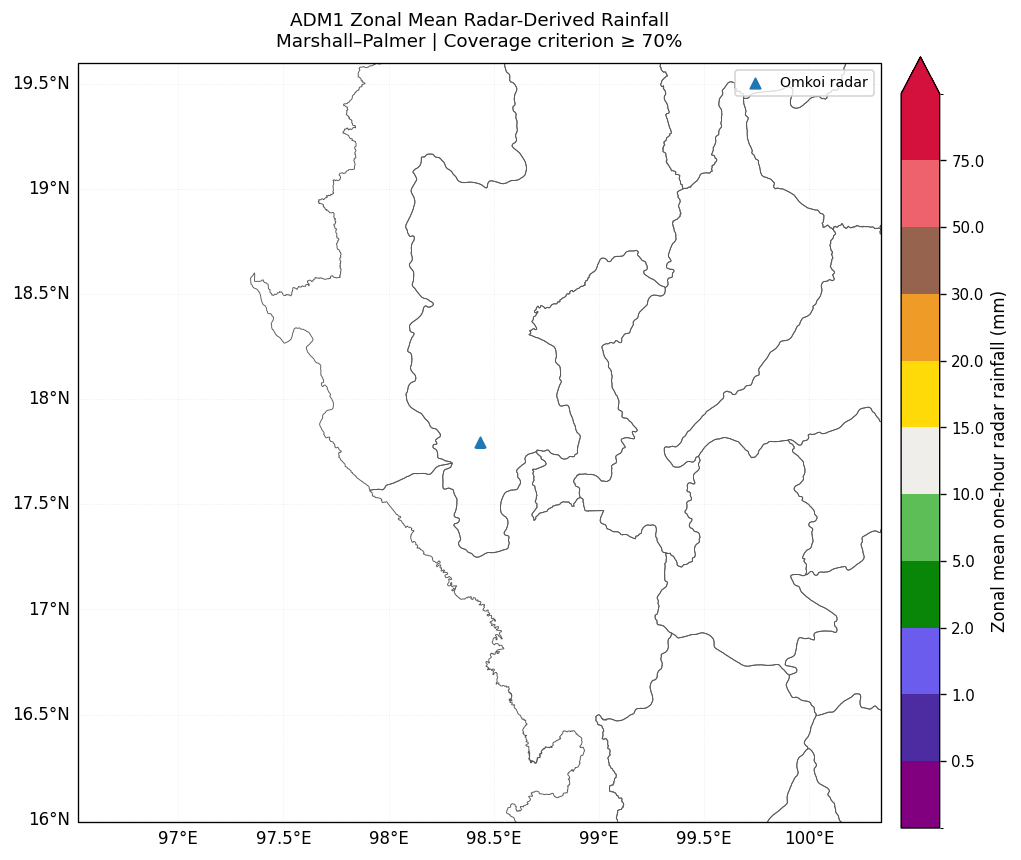

บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig08_ADM2_mean_hourly_rainfall.png


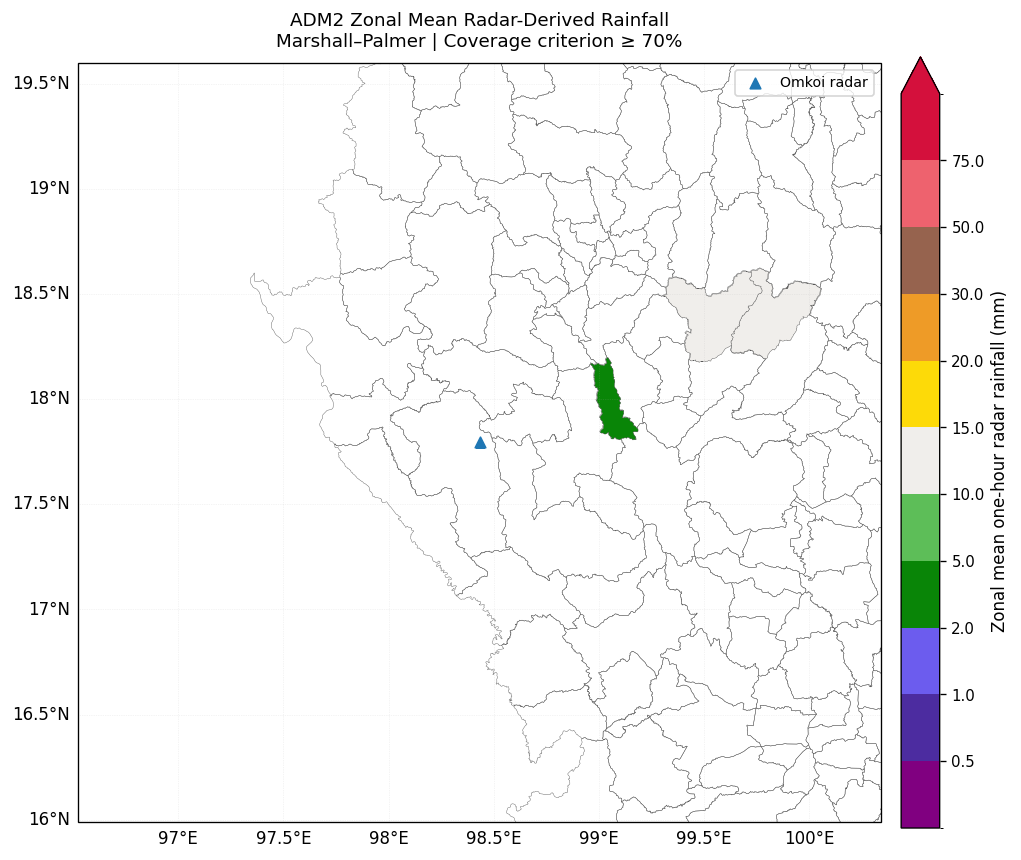

In [43]:
# CELL 43 — Export ADM1 and ADM2 choropleth maps

ADM1_MAP_FIG = (
    FIGURE_DIR
    / "05_fig07_ADM1_mean_hourly_rainfall.png"
)

ADM2_MAP_FIG = (
    FIGURE_DIR
    / "05_fig08_ADM2_mean_hourly_rainfall.png"
)

plot_zonal_mean_map(
    adm1_zonal_map,
    admin_level="ADM1",
    output_path=ADM1_MAP_FIG,
)

plot_zonal_mean_map(
    adm2_zonal_map,
    admin_level="ADM2",
    output_path=ADM2_MAP_FIG,
)

# 29. Ranking figures

In [44]:
# CELL 44 — Ranking bar-chart function

def plot_top_zones(
    ranking,
    *,
    relation_id,
    top_n,
    admin_level,
    output_path,
):
    subset = ranking[
        ranking[
            "relation_id"
        ]
        == relation_id
    ].copy()

    subset = (
        subset.sort_values(
            "mean_rainfall_mm",
            ascending=True,
        )
        .tail(
            top_n
        )
    )

    if subset.empty:
        print(
            f"No eligible {admin_level} zones for ranking figure."
        )
        return

    fig = plt.figure(
        figsize=(
            8.0,
            max(
                4.8,
                0.34
                * len(
                    subset
                )
                + 1.8,
            ),
        )
    )

    ax = fig.add_subplot(
        111
    )

    ax.barh(
        subset[
            "shapeName"
        ],
        subset[
            "mean_rainfall_mm"
        ],
    )

    ax.set_xlabel(
        "Zonal mean one-hour radar rainfall (mm)"
    )

    ax.set_ylabel(
        admin_level
    )

    ax.set_title(
        (
            f"Top {len(subset)} Wettest {admin_level} Zones\n"
            f"{ZR_RELATIONS[relation_id]['label']} | "
            f"Coverage ≥ "
            f"{MIN_ZONE_RADAR_COVERAGE_FRACTION:.0%}"
        )
    )

    ax.grid(
        axis="x",
        alpha=0.25,
        linestyle=":",
    )

    save_figure(
        fig,
        output_path,
        product=(
            f"top wettest {admin_level}"
        ),
        relation_id=(
            relation_id
        ),
        processing=(
            "Ranked by zonal mean hourly rainfall "
            "after radar-coverage filtering."
        ),
        units="mm",
        time_window=(
            f"{ANALYSIS_START_UTC} to "
            f"{ANALYSIS_END_UTC}"
        ),
    )

    plt.show()

No eligible ADM1 zones for ranking figure.
บันทึกรูป: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/05/05_fig10_top_ADM2.png


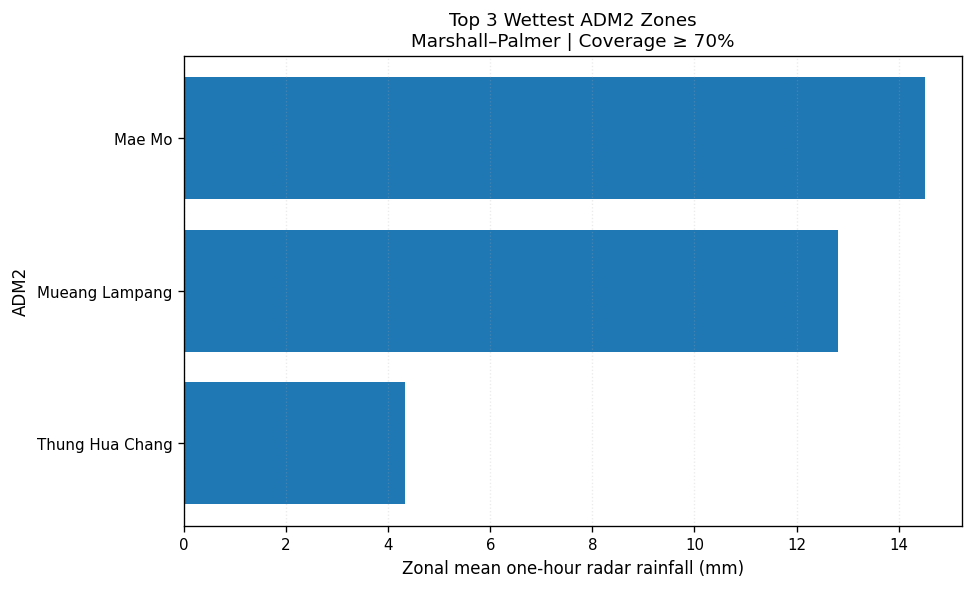

In [45]:
# CELL 45 — Export baseline ranking figures

TOP_ADM1_FIG = (
    FIGURE_DIR
    / "05_fig09_top_ADM1.png"
)

TOP_ADM2_FIG = (
    FIGURE_DIR
    / "05_fig10_top_ADM2.png"
)

plot_top_zones(
    TOP_ADM1,
    relation_id=BASE_RELATION,
    top_n=TOP_ADM1_N,
    admin_level="ADM1",
    output_path=TOP_ADM1_FIG,
)

plot_top_zones(
    TOP_ADM2,
    relation_id=BASE_RELATION,
    top_n=TOP_ADM2_N,
    admin_level="ADM2",
    output_path=TOP_ADM2_FIG,
)

# 30. สกัด hourly rainfall ที่จุดตัวอย่างจาก Notebook 04

Notebook 05 อ่านพิกัดจุดตัวอย่างจาก metadata ของ Notebook 04 และสกัดค่า:

- temporal coverage
- one-hour rainfall จากแต่ละ Z–R relation
- ระยะจาก requested point ถึง nearest grid-cell center

ผลนี้เป็น **hourly raster extraction** ไม่ใช่ gauge validation

In [46]:
# CELL 46 — Load point coordinates from Notebook 04 metadata

QPE_METADATA_04_CSV = (
    OUTPUT_CSV_DIR
    / "04_QPE_processing_metadata.csv"
)

if not QPE_METADATA_04_CSV.exists():
    raise FileNotFoundError(
        "ไม่พบ 04_QPE_processing_metadata.csv"
    )

metadata_04 = pd.read_csv(
    QPE_METADATA_04_CSV
)

metadata_04_lookup = dict(
    zip(
        metadata_04[
            "parameter"
        ],
        metadata_04[
            "value"
        ],
    )
)

POINT_LON = float(
    metadata_04_lookup[
        "point_lon"
    ]
)

POINT_LAT = float(
    metadata_04_lookup[
        "point_lat"
    ]
)

print(
    "Point from Notebook 04:",
    POINT_LON,
    POINT_LAT,
)

Point from Notebook 04: 99.31371291095486 18.030633492917154


In [47]:
# CELL 47 — Hourly raster point extractor

def extract_hourly_grid_point(
    array_internal,
    *,
    longitude,
    latitude,
):
    distance2 = (
        (
            grid_lon
            - longitude
        )**2
        + (
            grid_lat
            - latitude
        )**2
    )

    flat = int(
        np.nanargmin(
            distance2
        )
    )

    iy, ix = np.unravel_index(
        flat,
        distance2.shape,
    )

    value = np.ma.asarray(
        array_internal
    )[
        iy,
        ix
    ]

    return {
        "iy": iy,
        "ix": ix,
        "grid_lon": float(
            grid_lon[
                iy,
                ix
            ]
        ),
        "grid_lat": float(
            grid_lat[
                iy,
                ix
            ]
        ),
        "value": (
            float(
                value
            )
            if not np.ma.is_masked(
                value
            )
            else np.nan
        ),
    }


coverage_point = (
    extract_hourly_grid_point(
        np.ma.asarray(
            TEMPORAL_COVERAGE
        ),
        longitude=POINT_LON,
        latitude=POINT_LAT,
    )
)

point_hourly_rows = []

for relation_id, rainfall in (
    HOURLY_RAINFALL.items()
):
    extracted = (
        extract_hourly_grid_point(
            rainfall,
            longitude=POINT_LON,
            latitude=POINT_LAT,
        )
    )

    point_hourly_rows.append({
        "relation_id": (
            relation_id
        ),
        "label": (
            ZR_RELATIONS[
                relation_id
            ][
                "label"
            ]
        ),
        "requested_lon": (
            POINT_LON
        ),
        "requested_lat": (
            POINT_LAT
        ),
        "grid_lon": (
            extracted[
                "grid_lon"
            ]
        ),
        "grid_lat": (
            extracted[
                "grid_lat"
            ]
        ),
        "temporal_coverage_fraction": (
            coverage_point[
                "value"
            ]
        ),
        "one_hour_rainfall_mm": (
            extracted[
                "value"
            ]
        ),
    })


POINT_HOURLY = (
    pd.DataFrame(
        point_hourly_rows
    )
)

display(
    POINT_HOURLY
)

POINT_HOURLY_CSV = (
    OUTPUT_CSV_DIR
    / "05_point_hourly_extraction.csv"
)

POINT_HOURLY.to_csv(
    POINT_HOURLY_CSV,
    index=False,
)

,relation_id,label,requested_lon,requested_lat,grid_lon,grid_lat,temporal_coverage_fraction,one_hour_rainfall_mm
0,MP_200_1.6,Marshall–Palmer,99.313713,18.030633,99.311888,18.030061,0.998056,0.340371
1,CONV_300_1.4,Convective-like,99.313713,18.030633,99.311888,18.030061,0.998056,0.225848
2,TROP_250_1.2,Tropical-like,99.313713,18.030633,99.311888,18.030061,0.998056,0.214724


# 31. Export zonal results เป็น GeoPackage สำหรับ GIS

In [48]:
# CELL 48 — Export baseline zonal GeoPackage layers

OUTPUT_GPKG_DIR = Path(
    WORKSPACE[
        "output_gpkg"
    ]
)

OUTPUT_GPKG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

ZONAL_GPKG = (
    OUTPUT_GPKG_DIR
    / "05_hourly_rainfall_zonal_statistics.gpkg"
)

if ZONAL_GPKG.exists():
    ZONAL_GPKG.unlink()

adm1_zonal_map.to_file(
    ZONAL_GPKG,
    layer="ADM1_hourly_rainfall",
    driver="GPKG",
)

adm2_zonal_map.to_file(
    ZONAL_GPKG,
    layer="ADM2_hourly_rainfall",
    driver="GPKG",
)

print(
    "Saved:",
    ZONAL_GPKG,
)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/geopackage/05_hourly_rainfall_zonal_statistics.gpkg


# 32. ตรวจสอบ GeoTIFF products

In [49]:
# CELL 49 — GeoTIFF validation table

geotiff_validation_rows = []

for relation_id, path in (
    UTM_HOURLY_GEOTIFFS.items()
):
    with rasterio.open(
        path
    ) as src:

        data = src.read(
            1,
            masked=True,
        )

        geotiff_validation_rows.append({
            "relation_id": (
                relation_id
            ),
            "path": str(
                path
            ),
            "crs": str(
                src.crs
            ),
            "width": (
                src.width
            ),
            "height": (
                src.height
            ),
            "nodata": (
                src.nodata
            ),
            "valid_pixel_count": int(
                data.count()
            ),
            "min_rainfall_mm": (
                float(
                    data.min()
                )
                if data.count()
                else np.nan
            ),
            "max_rainfall_mm": (
                float(
                    data.max()
                )
                if data.count()
                else np.nan
            ),
        })


GEOTIFF_VALIDATION = (
    pd.DataFrame(
        geotiff_validation_rows
    )
)

display(
    GEOTIFF_VALIDATION
)

GEOTIFF_VALIDATION_CSV = (
    OUTPUT_CSV_DIR
    / "05_GeoTIFF_validation.csv"
)

GEOTIFF_VALIDATION.to_csv(
    GEOTIFF_VALIDATION_CSV,
    index=False,
)

,relation_id,path,crs,width,height,nodata,valid_pixel_count,min_rainfall_mm,max_rainfall_mm
0,MP_200_1.6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,403,401,-9999.0,6474,0.0,123.584732
1,CONV_300_1.4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,403,401,-9999.0,6474,0.0,203.484070
2,TROP_250_1.2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,EPSG:32647,403,401,-9999.0,6474,0.0,655.990662


# 33. Rainfall volume — ความหมายและข้อจำกัด

สำหรับแต่ละ valid pixel:

\[
V_i
=
P_i
\times
A_i
\]

โดย:

- \(P_i\) แปลงจาก mm เป็น m
- \(A_i\) คือพื้นที่ pixel หน่วย m²

ดังนั้น:

\[
V_i
\quad [m^3]
\]

Notebook นี้ใช้ native Cartesian grid ขนาดประมาณ 1 km × 1 km

rainfall volume ที่ได้เหมาะสำหรับ:

- การเปรียบเทียบเชิงพื้นที่
- การเรียน hydrometeorology/GIS
- การเชื่อมสู่ hydrology

แต่ยังไม่ใช่ runoff volume เพราะยังไม่มี:

- infiltration
- interception
- storage
- antecedent moisture
- routing

# 34. Export processing metadata

In [50]:
# CELL 50 — Processing metadata

PROCESSING_METADATA = pd.DataFrame({
    "parameter": [
        "radar_site",
        "radar_band",
        "source_field",
        "CAPPI_height_km_MSL",
        "grid_spacing_km",
        "grid_half_width_km",
        "weighting_function",
        "roi_function",
        "minimum_roi_m",
        "analysis_start_UTC",
        "analysis_end_UTC",
        "analysis_duration_h",
        "nominal_scan_interval_min",
        "scan_count",
        "dataset_temporal_completeness",
        "gap_factor",
        "minimum_pixel_temporal_coverage",
        "minimum_zone_radar_coverage",
        "wet_rain_threshold_mm",
        "area_threshold_1_mm",
        "area_threshold_2_mm",
        "pixel_area_km2",
        "zonal_rasterization_all_touched",
        "baseline_ZR_relation",
        "UTM_zone",
        "UTM_EPSG",
        "integration_method",
        "interpretation",
    ],
    "value": [
        "Omkoi",
        "S",
        FIELD_Z,
        QPE_CAPPI_MSL_KM,
        GRID_SPACING_KM,
        GRID_HALF_WIDTH_KM,
        WEIGHTING_FUNCTION,
        ROI_FUNCTION,
        MIN_RADIUS_M,
        str(
            ANALYSIS_START_UTC
        ),
        str(
            ANALYSIS_END_UTC
        ),
        ANALYSIS_DURATION_H,
        NOMINAL_INTERVAL_MIN,
        len(
            scan_time_inventory
        ),
        TEMPORAL_COMPLETENESS,
        GAP_FACTOR,
        MIN_TEMPORAL_COVERAGE_FRACTION,
        MIN_ZONE_RADAR_COVERAGE_FRACTION,
        WET_RAIN_THRESHOLD_MM,
        AREA_THRESHOLD_1_MM,
        AREA_THRESHOLD_2_MM,
        PIXEL_AREA_KM2,
        False,
        BASE_RELATION,
        (
            f"{UTM_INFO['zone']}"
            f"{UTM_INFO['hemisphere']}"
        ),
        UTM_INFO[
            "epsg"
        ],
        (
            "Forward interval integration: "
            "R_i × Δt_i; long gaps limited "
            "to nominal scan duration."
        ),
        (
            "Radar-derived rainfall sensitivity product; "
            "not gauge-validated."
        ),
    ],
})

display(
    PROCESSING_METADATA
)

PROCESSING_METADATA_CSV = (
    OUTPUT_CSV_DIR
    / "05_processing_metadata.csv"
)

PROCESSING_METADATA.to_csv(
    PROCESSING_METADATA_CSV,
    index=False,
)

print(
    "Saved:",
    PROCESSING_METADATA_CSV,
)

,parameter,value
0,radar_site,Omkoi
1,radar_band,S
2,source_field,corrected_reflectivity
3,CAPPI_height_km_MSL,2.0
4,grid_spacing_km,1.0
5,grid_half_width_km,200.0
6,weighting_function,Barnes2
7,roi_function,dist_beam
8,minimum_roi_m,500.0
9,analysis_start_UTC,2023-03-18 11:06:09+00:00


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/05_processing_metadata.csv


# 35. Export figure manifest

In [51]:
# CELL 51 — Figure manifest

FIGURE_MANIFEST = pd.DataFrame(
    FIGURE_RECORDS
)

FIGURE_MANIFEST_CSV = (
    OUTPUT_CSV_DIR
    / "05_figure_manifest.csv"
)

FIGURE_MANIFEST.to_csv(
    FIGURE_MANIFEST_CSV,
    index=False,
)

display(
    FIGURE_MANIFEST
)

print(
    "Saved:",
    FIGURE_MANIFEST_CSV,
)

,figure_name,figure_path,source_file,product,relation_id,processing,units,time_window,dpi
0,05_fig01_scan_interval_QC.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,scan interval QC,None,Actual radar timestamps; conservative interval...,minutes,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
1,05_fig02_temporal_coverage.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,temporal coverage,None,Accumulated radar-support duration divided by ...,fraction,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
2,05_hourly_rainfall_MP_200_1.6.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,hourly radar rainfall,MP_200_1.6,Interval integration; ZH >= 10.0 dBZ; pixel te...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
3,05_hourly_rainfall_CONV_300_1.4.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,hourly radar rainfall,CONV_300_1.4,Interval integration; ZH >= 10.0 dBZ; pixel te...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
4,05_hourly_rainfall_TROP_250_1.2.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,hourly radar rainfall,TROP_250_1.2,Interval integration; ZH >= 10.0 dBZ; pixel te...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
5,05_fig06_hourly_rainfall_distribution.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,hourly rainfall distribution,None,Wet analysis-ready pixels only; comparison amo...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
6,05_fig07_ADM1_mean_hourly_rainfall.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,ADM1 zonal mean rainfall,MP_200_1.6,Pixel-center rasterization; zone radar coverag...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
7,05_fig08_ADM2_mean_hourly_rainfall.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,ADM2 zonal mean rainfall,MP_200_1.6,Pixel-center rasterization; zone radar coverag...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300
8,05_fig10_top_ADM2.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,None,top wettest ADM2,MP_200_1.6,Ranked by zonal mean hourly rainfall after rad...,mm,2023-03-18 11:06:09+00:00 to 2023-03-18 12:06:...,300


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/events/20230318_observed_hail_1106_1200/03_output/csv/05_figure_manifest.csv


# 36. แนวทางเขียน Methods

ควรดึงค่าจริงจาก:

```text
05_scan_interval_QC.csv
05_processing_metadata.csv
04_ZR_relation_parameters.csv
```

ตัวอย่างโครงสร้างข้อความ:

> Radar-derived rain rates were generated at a constant altitude of 2 km MSL using a common 1-km Cartesian grid for all radar volumes. One-hour rainfall accumulation was calculated by forward interval integration, \(P_i=R_i\Delta t_i\), using the actual radar timestamps. For temporal gaps exceeding 1.5 times the nominal scan interval, the preceding rain-rate field was applied only for one nominal scan duration, leaving the remaining interval unfilled. Pixel-level hourly rainfall was retained only where temporal radar coverage reached at least 80%. Administrative zonal statistics were calculated on the native radar Cartesian grid using pixel-center polygon rasterization, and zones with less than 70% valid radar coverage were excluded from wettest-area rankings.

ข้อความจริงใน manuscript ต้องรายงาน Z–R relation และ threshold ที่ใช้จริงด้วย

# 37. ประเด็นเชิงวิทยาศาสตร์ที่ต้องระวัง

### 1. ห้าม sum dBZ

\[
dBZ_1+dBZ_2+\cdots
\]

ไม่มีความหมายเป็น rainfall accumulation

ต้องแปลง:

```text
dBZ → Z → R → RΔt → rainfall depth
```

### 2. Supported dry pixel ไม่เท่ากับ missing pixel

```text
valid radar support + ZH < threshold
→ rainfall = 0

no radar support
→ NoData
```

### 3. Missing scan ต้องปรากฏใน coverage

ห้าม interpolate temporal gap โดยไม่รายงาน

### 4. Zonal mean ต้องอ่านคู่กับ coverage

เขตที่ mean สูงแต่ coverage ต่ำอาจให้ภาพที่ทำให้เข้าใจผิด

### 5. Rainfall volume ไม่เท่ากับ runoff volume

ต้องมี hydrological processes เพิ่มเติมก่อนวิเคราะห์ runoff

# 38. แบบฝึกหัดระดับ CORE

### แบบฝึกหัด 1 — Rain rate → rainfall depth

ถ้า:

\[
R=20\;mm\,h^{-1}
\]

และ:

\[
\Delta t=6\;min
\]

คำนวณ rainfall depth

### แบบฝึกหัด 2 — ตรวจ scan interval

ใช้ `05_scan_interval_QC.csv` ตอบ:

- median interval เท่าใด?
- มี gap หรือไม่?
- temporal completeness เท่าใด?

### แบบฝึกหัด 3 — Hourly QPE

เปรียบเทียบ:

- mean
- P95
- maximum

ของ Z–R relations ทั้งสาม

### แบบฝึกหัด 4 — Zonal statistics

เลือกจังหวัดหนึ่งและอำเภอหนึ่ง รายงาน:

- mean rainfall
- P95
- max
- wet-area fraction
- radar coverage fraction

# 39. แบบฝึกหัดระดับ ADVANCED / MSc

### แบบฝึกหัด 5 — Missing scan experiment

จำลองให้ไฟล์หนึ่งหายจากรายการ แล้วรัน temporal QC ใหม่

ตอบว่า:

- temporal completeness ลดลงเท่าใด?
- temporal-coverage map เปลี่ยนอย่างไร?
- ควรตีความ hourly total อย่างไร?

### แบบฝึกหัด 6 — Coverage threshold sensitivity

เปรียบเทียบ:

```text
70%
80%
90%
```

สำหรับ minimum pixel temporal coverage

ตรวจผลต่อ:

- valid hourly pixels
- zonal mean
- wettest-area ranking

### แบบฝึกหัด 7 — Zonal rasterization

เปรียบเทียบ:

```python
all_touched=False
```

กับ:

```python
all_touched=True
```

โดยเฉพาะอำเภอขนาดเล็กและขอบเขตซับซ้อน

อภิปรายผลต่อพื้นที่และ zonal mean

# 40. แบบฝึกหัดระดับ RESEARCH

### แบบฝึกหัด 8 — Integration method sensitivity

เปรียบเทียบ forward interval integration กับ trapezoidal integration ใน point time series ที่ข้อมูลครบ

อภิปรายว่า assumption ของแต่ละวิธีต่างกันอย่างไร

### แบบฝึกหัด 9 — Rainfall-volume interpretation

เลือก ADM1 หนึ่งเขตแล้วเปรียบเทียบ:

- zonal mean rainfall
- wet area
- rainfall volume

อธิบายว่าเหตุใดเขตที่ mean rainfall สูงที่สุดอาจไม่ใช่เขตที่ rainfall volume สูงที่สุด

### แบบฝึกหัด 10 — Publication figure

เลือกหนึ่งใน:

- hourly rainfall map
- ADM1 choropleth
- ADM2 choropleth
- wettest-zone ranking

เขียน figure caption ที่ระบุ:

- radar site
- time window
- CAPPI height
- Z–R relation
- temporal integration
- coverage criterion
- administrative level
- ข้อจำกัดว่าเป็น radar-derived rainfall

# 41. สิ่งที่ Notebook 05 ยังไม่ทำ

Notebook นี้ยังไม่ทำ:

- rain-gauge bias correction
- gauge validation
- multi-hour/day accumulation
- hydrological runoff modeling
- storm-object tracking
- echo-top / VIL / VILD
- hail retrieval

หลัง Notebook 05 หลักสูตรจะเปลี่ยนจากสาย QPE ไปสู่:

**Notebook 06 — โครงสร้างแนวดิ่งของพายุและการวิเคราะห์ cross section**

# 42. Final readiness check

In [52]:
# CELL 52 — Notebook 05 readiness

checks = []

def add_check(
    item,
    passed,
    note="",
):
    checks.append({
        "item": item,
        "status": (
            "PASS"
            if passed
            else "FAIL"
        ),
        "note": note,
    })


add_check(
    "Notebook 04 readiness",
    bool(
        (
            readiness_04[
                "status"
            ]
            == "PASS"
        ).all()
    ),
)

add_check(
    "Radar volume count",
    len(
        scan_time_inventory
    )
    == 10,
    (
        f"Observed "
        f"{len(scan_time_inventory)} volumes"
    ),
)

add_check(
    "Nominal scan interval approximately 6 min",
    np.isclose(
        NOMINAL_INTERVAL_MIN,
        6.0,
        atol=0.25,
    ),
    (
        f"{NOMINAL_INTERVAL_MIN:.2f} min"
    ),
)

add_check(
    "Dataset temporal completeness >= 95%",
    TEMPORAL_COMPLETENESS
    >= 0.95,
    (
        f"{TEMPORAL_COMPLETENESS:.1%}"
    ),
)

add_check(
    "Common single-level radar grid created",
    GRID_TEMPLATE
    is not None,
)

add_check(
    "Three hourly rainfall products created",
    len(
        HOURLY_RAINFALL
    )
    == len(
        ZR_RELATIONS
    ),
)

add_check(
    "Hourly rainfall summary exported",
    HOURLY_QPE_SUMMARY_CSV.exists(),
)

add_check(
    "Temporal coverage summary exported",
    TEMPORAL_COVERAGE_CSV.exists(),
)

add_check(
    "ADM1 zonal statistics exported",
    ADM1_STATS_CSV.exists(),
)

add_check(
    "ADM2 zonal statistics exported",
    ADM2_STATS_CSV.exists(),
)

add_check(
    "Wettest ADM1 ranking exported",
    TOP_ADM1_CSV.exists(),
)

add_check(
    "Wettest ADM2 ranking exported",
    TOP_ADM2_CSV.exists(),
)

add_check(
    "Hourly UTM GeoTIFFs created",
    all(
        path.exists()
        for path in (
            UTM_HOURLY_GEOTIFFS.values()
        )
    ),
)

add_check(
    "Temporal-coverage GeoTIFF created",
    TEMPORAL_COVERAGE_UTM_GEOTIFF.exists(),
)

add_check(
    "GeoTIFF validation exported",
    GEOTIFF_VALIDATION_CSV.exists(),
)

add_check(
    "Point hourly extraction exported",
    POINT_HOURLY_CSV.exists(),
)

add_check(
    "Zonal GeoPackage created",
    ZONAL_GPKG.exists(),
)

add_check(
    "Processing metadata exported",
    PROCESSING_METADATA_CSV.exists(),
)

add_check(
    "Figure manifest exported",
    FIGURE_MANIFEST_CSV.exists(),
)


READINESS_05 = pd.DataFrame(
    checks
)

display(
    READINESS_05
)

NOTEBOOK_05_READY = bool(
    (
        READINESS_05[
            "status"
        ]
        == "PASS"
    ).all()
)

READINESS_05_CSV = (
    OUTPUT_CSV_DIR
    / "05_readiness_check.csv"
)

READINESS_05.to_csv(
    READINESS_05_CSV,
    index=False,
)

print()

print(
    (
        "NOTEBOOK 05 READY FOR VERTICAL STORM-STRUCTURE ANALYSIS"
    )
    if NOTEBOOK_05_READY
    else "NOTEBOOK 05 REQUIRES REVIEW"
)

,item,status,note
0,Notebook 04 readiness,PASS,
1,Radar volume count,PASS,Observed 10 volumes
2,Nominal scan interval approximately 6 min,PASS,6.00 min
3,Dataset temporal completeness >= 95%,PASS,99.8%
4,Common single-level radar grid created,PASS,
5,Three hourly rainfall products created,PASS,
6,Hourly rainfall summary exported,PASS,
7,Temporal coverage summary exported,PASS,
8,ADM1 zonal statistics exported,PASS,
9,ADM2 zonal statistics exported,PASS,



NOTEBOOK 05 READY FOR VERTICAL STORM-STRUCTURE ANALYSIS


# ข้อความสำคัญที่ต้องจำ

1. **Rain rate (mm h⁻¹) ไม่ใช่ rainfall accumulation (mm)**
2. การสะสมฝนต้องคำนวณ \(R_i\Delta t_i\)
3. **ห้าม sum dBZ**
4. ต้องใช้ timestamp จริง ไม่ hard-code interval โดยไม่ตรวจสอบ
5. Missing scans ต้องปรากฏใน temporal completeness
6. Supported dry pixels ต้องเป็น 0 rainfall ไม่ใช่ NoData
7. No radar support ต้องเป็น NoData
8. ทุก scan ต้องใช้ grid geometry เดียวกันก่อน temporal integration
9. Hourly rainfall ควรมี temporal-coverage raster ควบคู่
10. Zonal statistics ต้องรายงาน radar coverage fraction
11. เขตที่ coverage ต่ำไม่ควรถูกจัดอันดับเทียบโดยตรง
12. Zonal mean rainfall กับ rainfall volume ตอบคำถามต่างกัน
13. Rasterization rule เป็น processing choice ที่ต้องรายงาน
14. Z–R sensitivity ยังคงมีผลต่อ hourly accumulation
15. Radar-derived rainfall ยังไม่ใช่ ground truth

# Expected outputs

```text
03_output/csv/
├── 05_scan_interval_QC.csv
├── 05_scan_QPE_summary.csv
├── 05_temporal_coverage_summary.csv
├── 05_hourly_QPE_summary.csv
├── 05_ADM1_zonal_statistics.csv
├── 05_ADM2_zonal_statistics.csv
├── 05_top_wettest_ADM1.csv
├── 05_top_wettest_ADM2.csv
├── 05_point_hourly_extraction.csv
├── 05_GeoTIFF_validation.csv
├── 05_processing_metadata.csv
├── 05_figure_manifest.csv
└── 05_readiness_check.csv

03_output/geotiff/
├── 05_hourly_rainfall_MP_200_1.6_native_AEQD.tif
├── 05_hourly_rainfall_MP_200_1.6_UTM47N.tif
├── 05_hourly_rainfall_CONV_300_1.4_native_AEQD.tif
├── 05_hourly_rainfall_CONV_300_1.4_UTM47N.tif
├── 05_hourly_rainfall_TROP_250_1.2_native_AEQD.tif
├── 05_hourly_rainfall_TROP_250_1.2_UTM47N.tif
├── 05_temporal_coverage_native_AEQD.tif
└── 05_temporal_coverage_UTM47N.tif

03_output/geopackage/
└── 05_hourly_rainfall_zonal_statistics.gpkg
    ├── ADM1_hourly_rainfall
    └── ADM2_hourly_rainfall

04_figures/05/
├── scan interval QC
├── temporal coverage
├── hourly rainfall maps × 3
├── hourly rainfall distribution
├── ADM1 zonal mean map
├── ADM2 zonal mean map
├── top ADM1 ranking
└── top ADM2 ranking
```

เมื่อ cell สุดท้ายแสดง:

```text
NOTEBOOK 05 READY FOR VERTICAL STORM-STRUCTURE ANALYSIS
```

จึงเข้าสู่:

**Notebook 06 — โครงสร้างแนวดิ่งของพายุ, pseudo-RHI, cross section และ echo-top concepts**